# 👩‍💻Perform EDA on Your Project Dataset

## 📋 Overview
In this hands-on activity, you will apply Exploratory Data Analysis (EDA) techniques to gain a comprehensive understanding of your selected dataset. EDA is foundational for identifying data distributions, relationships, and anomalies, which are crucial for informed decision-making in machine learning projects. Mastery of EDA practices is valuable for data analysts and data scientists as it informs subsequent modeling phases.

## 🎯 Activity Goals
By completing this activity, you will:
- Analyze and interpret data distributions and central tendencies
- Identify relationships and correlations between feature pairs
- Detect and critically assess outliers and anomalies
- Synthesize findings into a concise analytical report

## 🌎 Scenario
You are a data analyst tasked with preparing a dataset for an upcoming machine learning project. The project requires a thorough understanding of the data to guide strategic decisions in feature engineering and eventual model selection. Your responsibility is to perform all necessary EDA steps to ensure your team has a clear grasp of the dataset's traits and potential challenges.

<b>Reminder:</b> A number of dataset csv files have been uploaded to this lab environment. Choose one dataset from the following options:
- Customer Churn (Telecom): `Telco-Customer-Churn.csv`
- Credit Card Fraud Detection: `creditcard.csv`
- Bike Sharing Demand Forecasting:` bikeshareday.csv`
- IMDb Sentiment Analysis (NLP): `IMDB_Dataset.csv`
- Customer Segmentation (Clustering): `marketing_campaign.csv`

In [1]:
# Load the dataset
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
import warnings 
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 10000)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Step 1: Select Your Dataset
From the following options, choose a dataset to explore: Customer Churn, Credit Card Fraud Detection, Bike Sharing Demand Forecasting, IMDb Sentiment Analysis, or Customer Segmentation.

In [2]:
# Your code here
df= pd.read_csv("creditcard.csv")

# Explore the data
print(f"Shape of Data: {df.shape}")
print("\n----- Top 5 Rows of Data ------")
display(df.head())
print("\n----- Information of Data ------")
print(df.info())
print("\n----- Summmary of Data ------")
display(df.describe(percentiles=[i/100 for i in range(0, 101) if i%5==0]).T)
print("\n------- Number of Null Values ---------")
print(df.isnull().sum())

print("Class Count:\n", df['Class'].value_counts(dropna=False))

print("Class distribution:\n", df['Class'].value_counts(dropna=False, normalize=True))

Shape of Data: (95162, 31)

----- Top 5 Rows of Data ------


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0



----- Information of Data ------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95162 entries, 0 to 95161
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    95162 non-null  int64  
 1   V1      95162 non-null  float64
 2   V2      95162 non-null  float64
 3   V3      95162 non-null  float64
 4   V4      95162 non-null  float64
 5   V5      95162 non-null  float64
 6   V6      95162 non-null  float64
 7   V7      95162 non-null  float64
 8   V8      95162 non-null  float64
 9   V9      95162 non-null  float64
 10  V10     95162 non-null  float64
 11  V11     95162 non-null  float64
 12  V12     95162 non-null  float64
 13  V13     95161 non-null  float64
 14  V14     95161 non-null  float64
 15  V15     95161 non-null  float64
 16  V16     95161 non-null  float64
 17  V17     95161 non-null  float64
 18  V18     95161 non-null  float64
 19  V19     95161 non-null  float64
 20  V20     95161 non-null  float64
 21  V

,count,mean,std,min,0%,5%,10%,15%,20%,25%,30%,35%,40%,45%,50%,55%,60%,65%,70%,75%,80%,85%,90%,95%,100%,max
Time,95162.0,41220.807318,16579.974524,0.000000,0.000000,4208.050000,14181.200000,25342.150000,29968.000000,32919.250000,35051.000000,37182.350000,39235.000000,41260.450000,43264.500000,45396.000000,47752.000000,50017.300000,52130.000000,54272.750000,56407.800000,58697.850000,60867.000000,63006.000000,65191.000000,65191.000000
V1,95162.0,-0.264142,1.867765,-56.407510,-56.407510,-3.055517,-2.011825,-1.545421,-1.246471,-1.028614,-0.855628,-0.710766,-0.566194,-0.417879,-0.260319,0.443140,0.905135,1.032988,1.103213,1.153098,1.191915,1.231104,1.273935,1.344210,1.960497,1.960497
V2,95162.0,-0.037406,1.662025,-72.715728,-72.715728,-2.092871,-1.352693,-1.024360,-0.789009,-0.603497,-0.435166,-0.282203,-0.151074,-0.035246,0.074743,0.181521,0.284673,0.405165,0.569901,0.732010,0.906756,1.069958,1.269243,1.728733,18.902453,18.902453
V3,95162.0,0.676465,1.335794,-33.680984,-33.680984,-1.096738,-0.453694,-0.168479,0.024563,0.178324,0.304238,0.417657,0.527594,0.640845,0.756464,0.882823,1.008233,1.129939,1.250630,1.380144,1.536636,1.709944,1.941126,2.287336,4.226108,4.226108
V4,95162.0,0.162307,1.352735,-5.172595,-5.172595,-2.009274,-1.553369,-1.268919,-0.949353,-0.716021,-0.531200,-0.310049,-0.119933,0.036109,0.188995,0.367640,0.532402,0.686184,0.847713,1.032434,1.195021,1.361217,1.649274,2.491765,16.715537,16.715537
V5,95162.0,-0.279595,1.365154,-42.147898,-42.147898,-1.869114,-1.474999,-1.230534,-1.050634,-0.898671,-0.761433,-0.632874,-0.517194,-0.412720,-0.313955,-0.212404,-0.106659,0.002175,0.117493,0.250962,0.411689,0.637588,1.009978,1.807071,34.801666,34.801666
V6,95162.0,0.093487,1.302887,-26.160506,-26.160506,-1.269135,-1.041629,-0.883564,-0.757338,-0.647761,-0.547119,-0.450652,-0.350265,-0.252174,-0.157090,-0.050345,0.056593,0.179788,0.318223,0.486449,0.701108,0.989499,1.509500,3.211357,22.529298,22.529298
V7,95162.0,-0.107723,1.221749,-31.764946,-31.764946,-1.396640,-1.076700,-0.858363,-0.713618,-0.600284,-0.493141,-0.377303,-0.258965,-0.157320,-0.068859,0.012734,0.094465,0.188528,0.296318,0.416310,0.542271,0.668032,0.847344,1.179915,36.677268,36.677268
V8,95162.0,0.055063,1.208737,-73.216718,-73.216718,-0.779129,-0.360453,-0.254893,-0.191065,-0.138858,-0.091758,-0.049786,-0.009724,0.030458,0.072532,0.115457,0.163091,0.215833,0.278934,0.357561,0.463116,0.604365,0.779133,1.042410,20.007208,20.007208
V9,95162.0,-0.038993,1.127677,-9.283925,-9.283925,-1.819122,-1.327720,-1.042421,-0.847326,-0.697376,-0.564307,-0.446486,-0.328407,-0.217616,-0.112566,-0.009781,0.102819,0.237224,0.388626,0.570972,0.772513,1.004862,1.309129,1.830759,10.392889,10.392889



------- Number of Null Values ---------
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64
Class Count:
 Class
0.0    94944
1.0      217
NaN        1
Name: count, dtype: int64
Class distribution:
 Class
0.0    0.997709
1.0    0.002280
NaN    0.000011
Name: proportion, dtype: float64


<b>💡 Tip:</b> Consider choosing a dataset that aligns with your personal or professional interests for a more engaging analysis.

<b>❗ Common Mistakes</b>
- Not reviewing dataset documentation for context.
- Overlooking metadata related to feature meanings.

## Step 2: Visualize Data Distributions
- Use histograms and box plots to examine the distribution of at least two numerical features.
- Note any skewness, central tendencies, or abnormalities in these distributions.

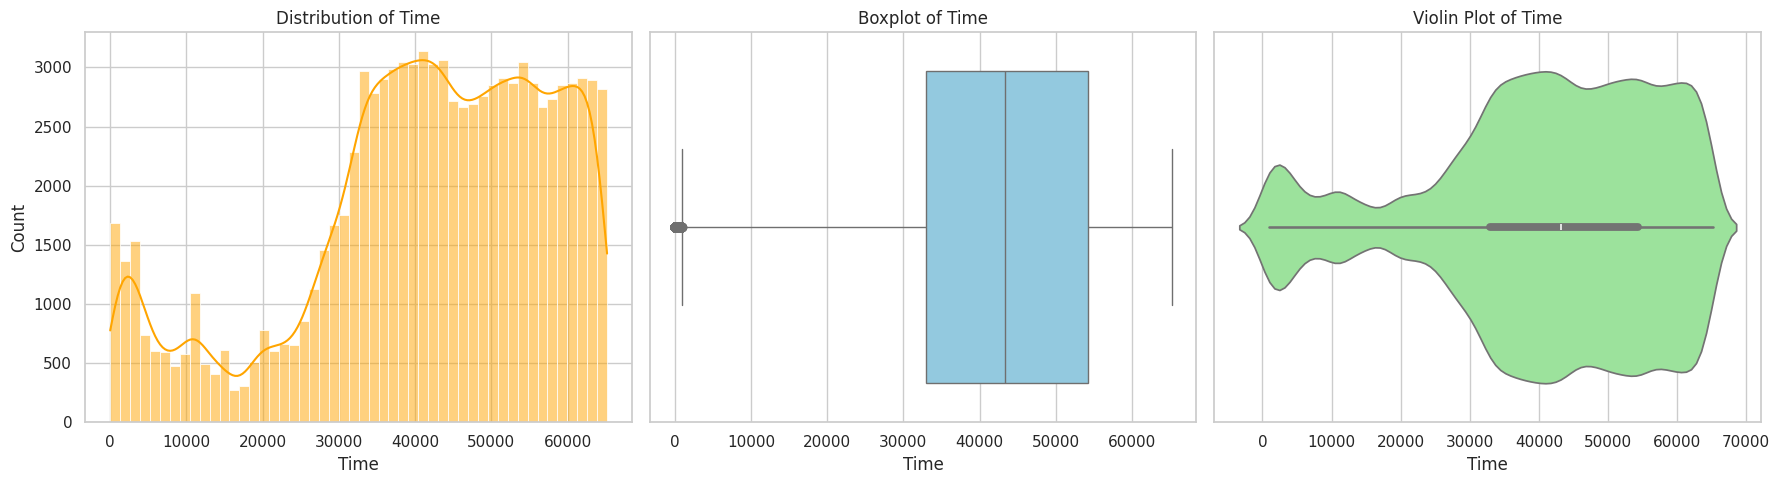

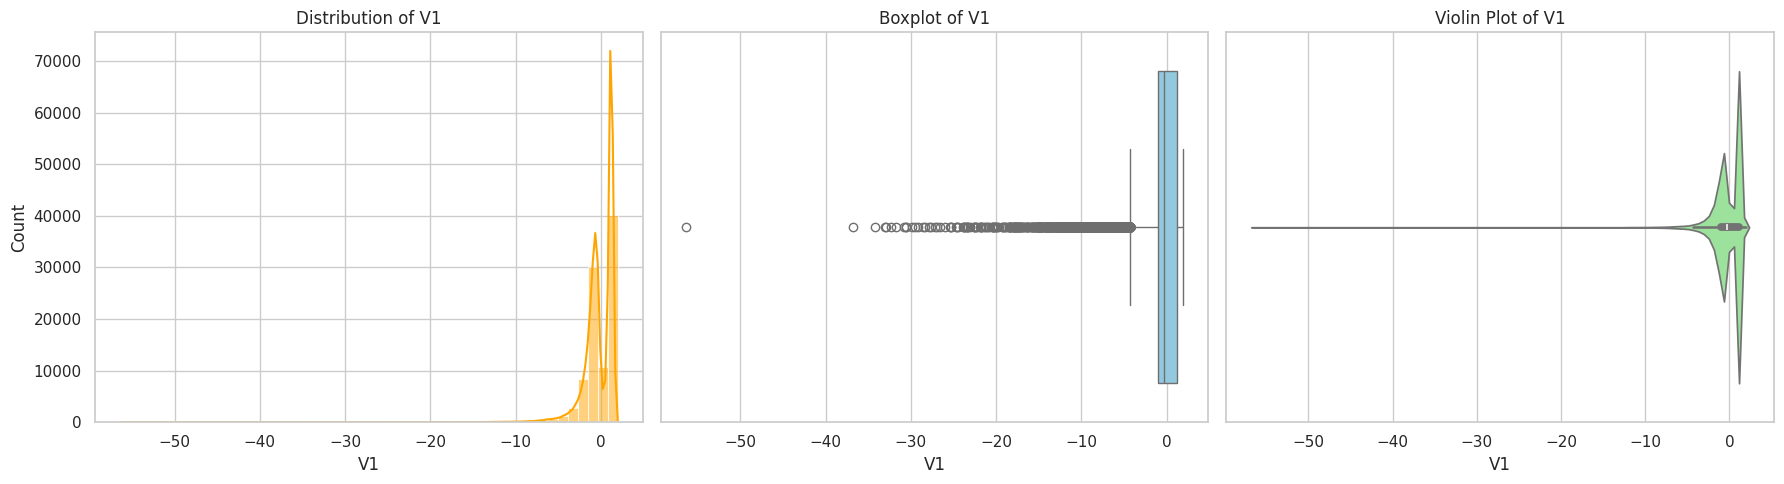

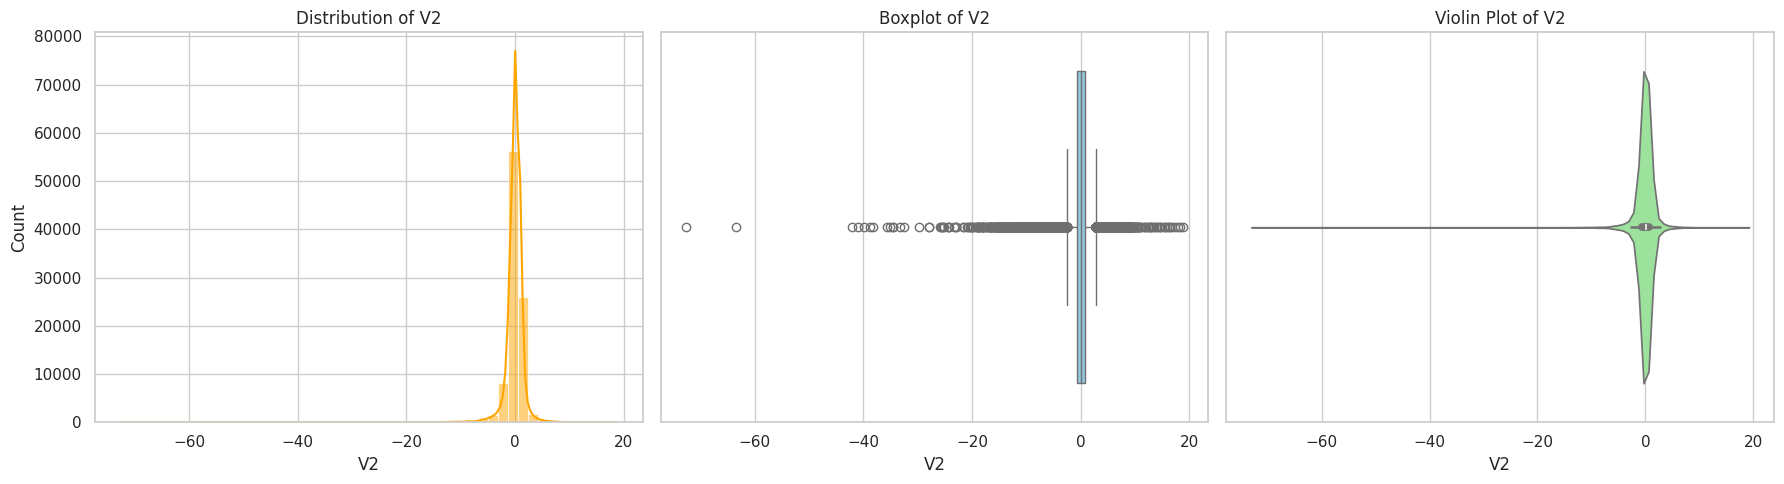

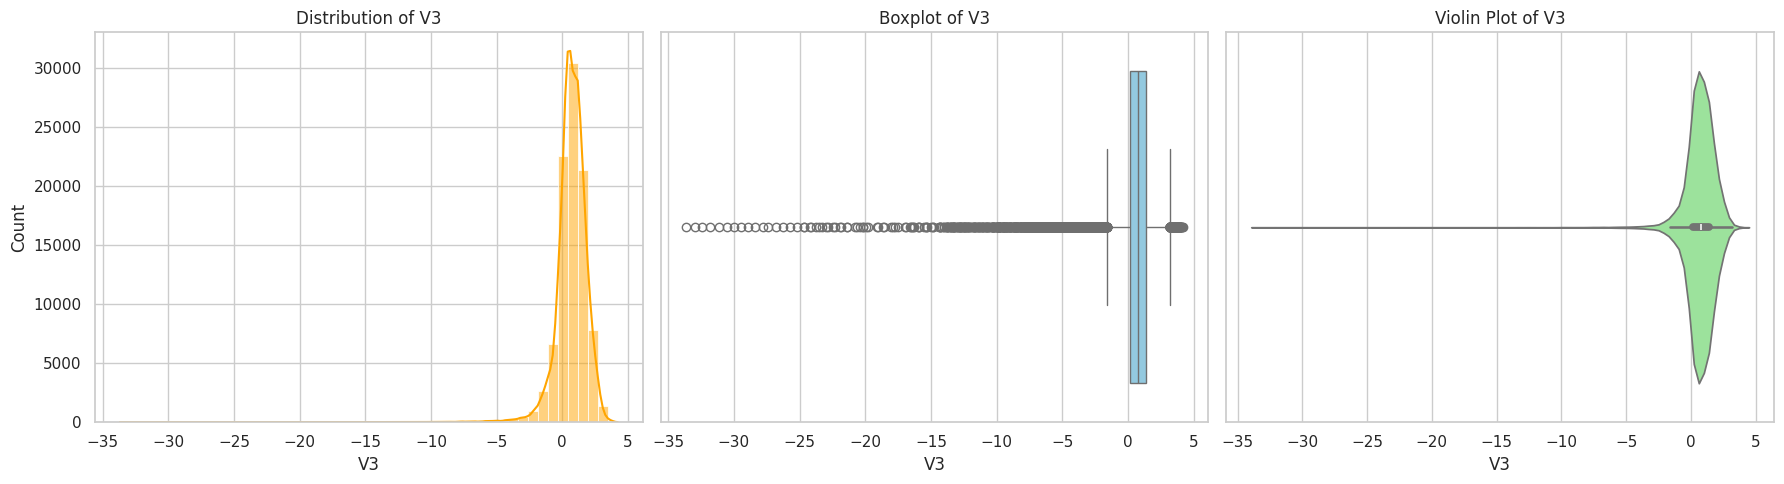

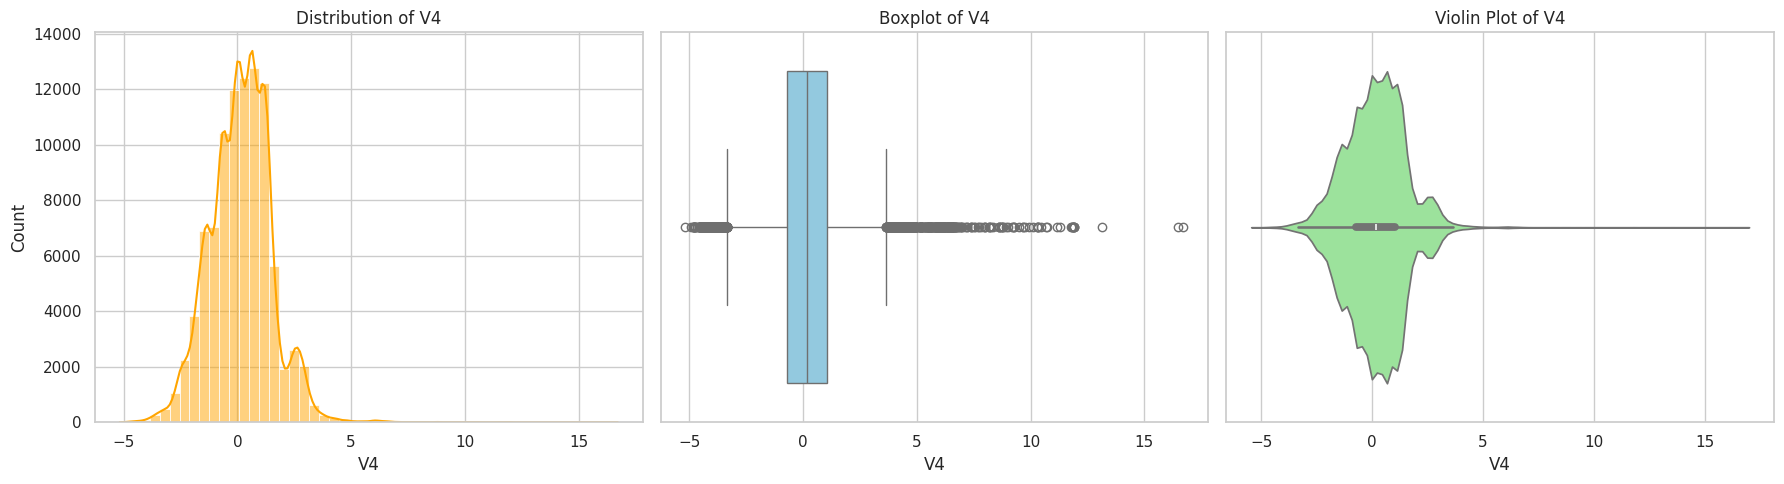

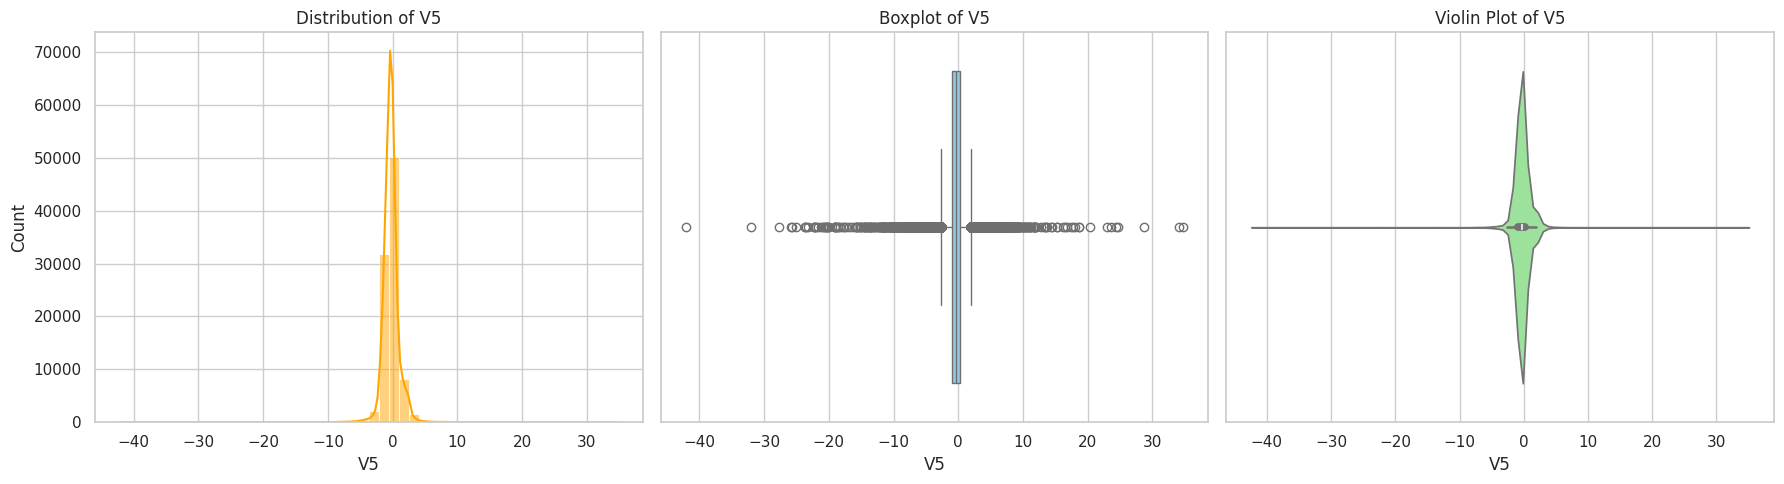

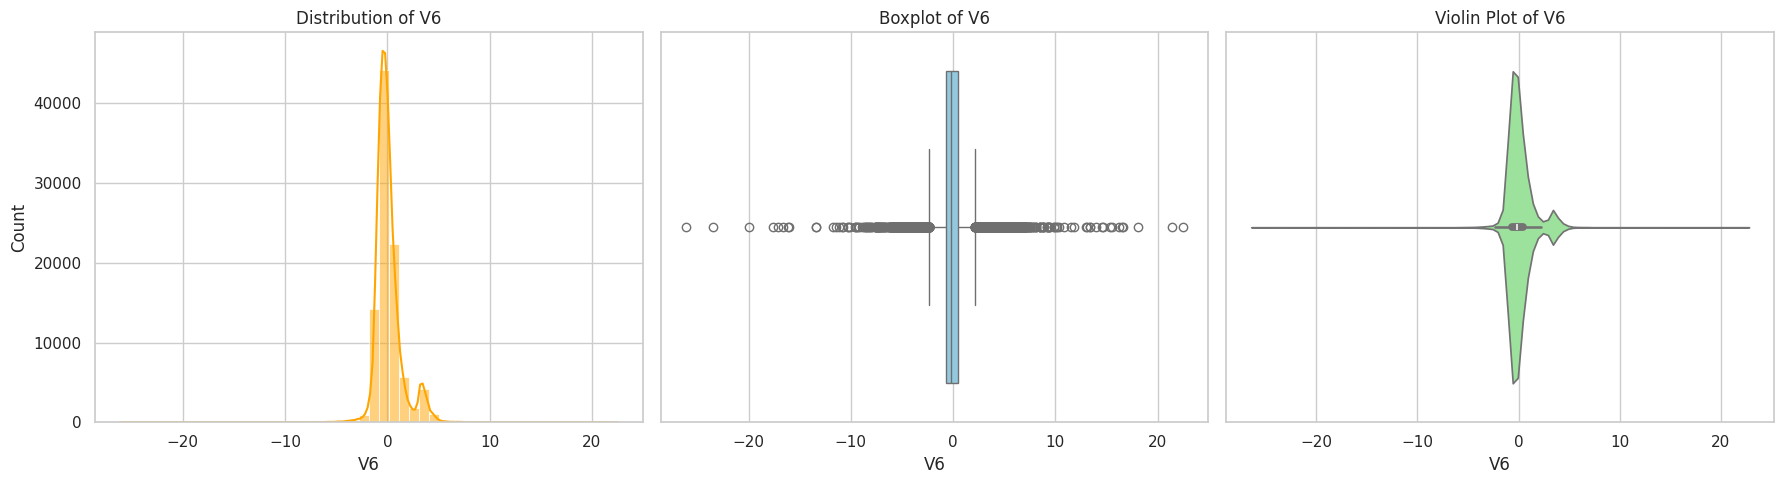

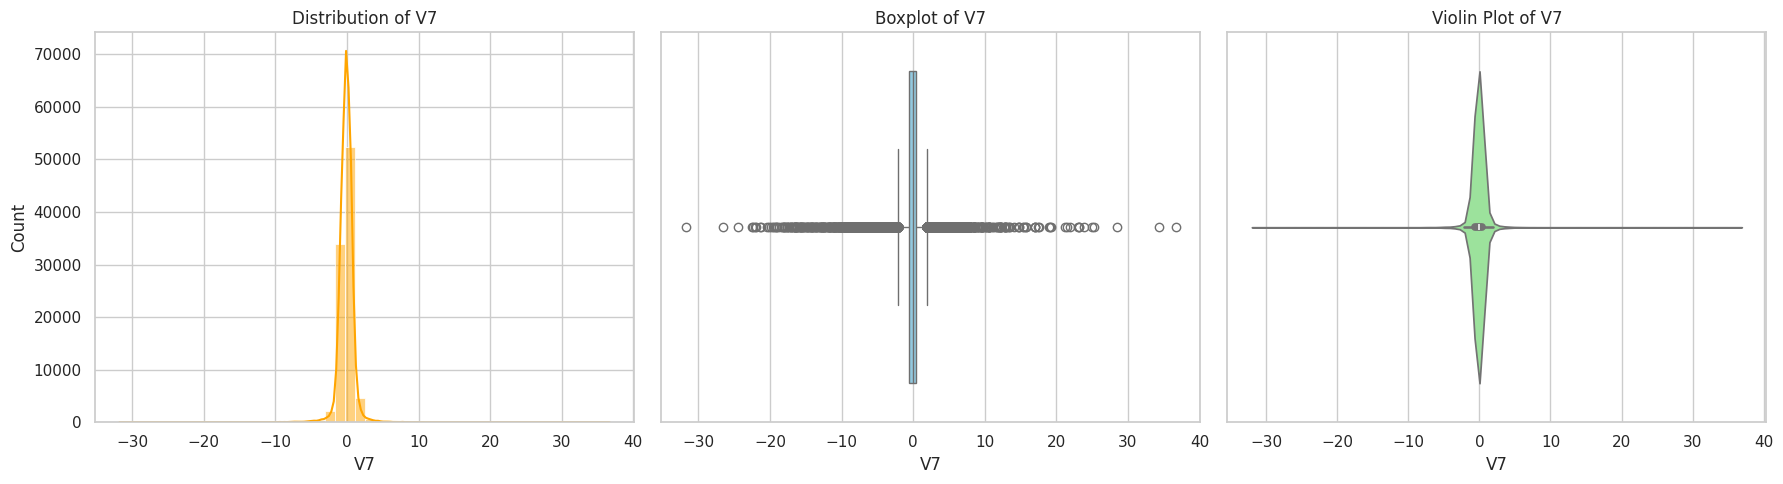

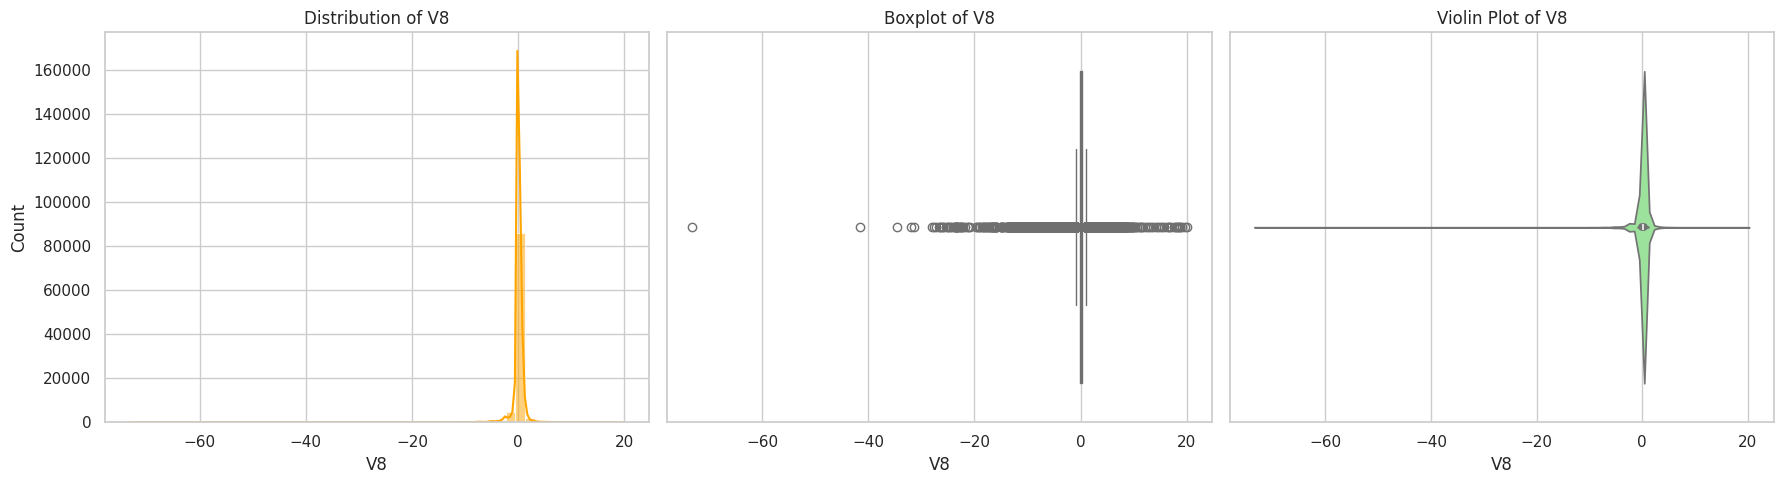

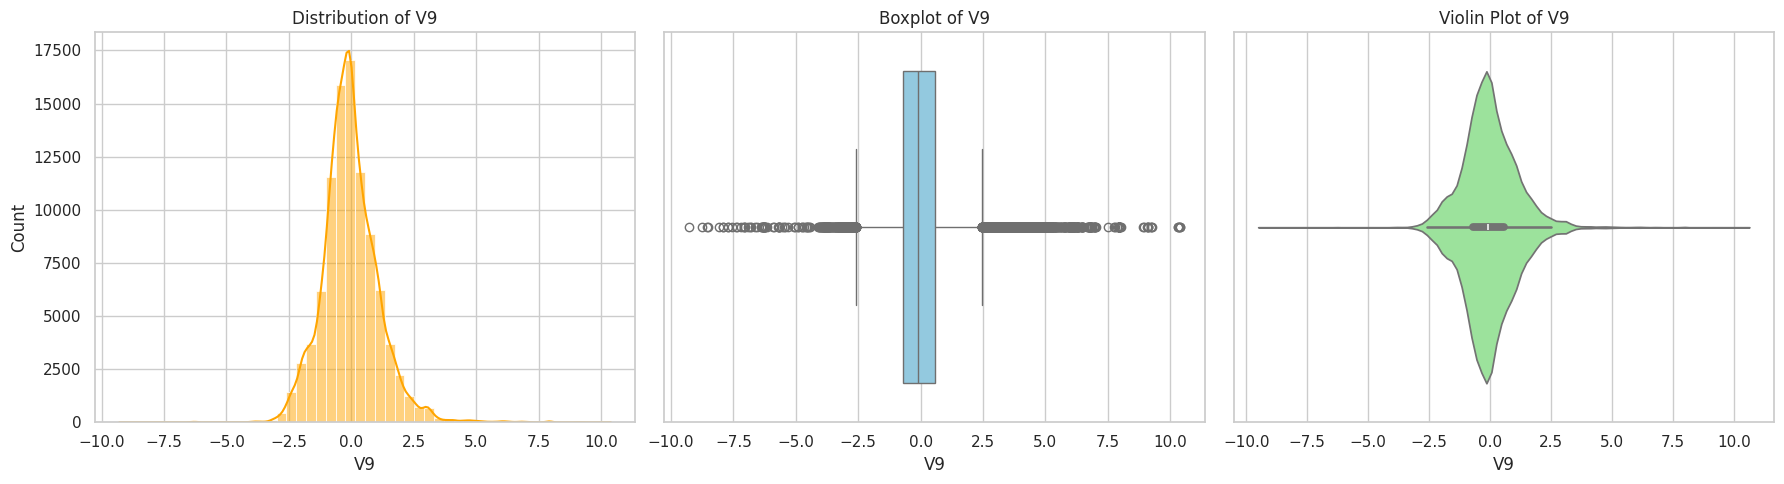

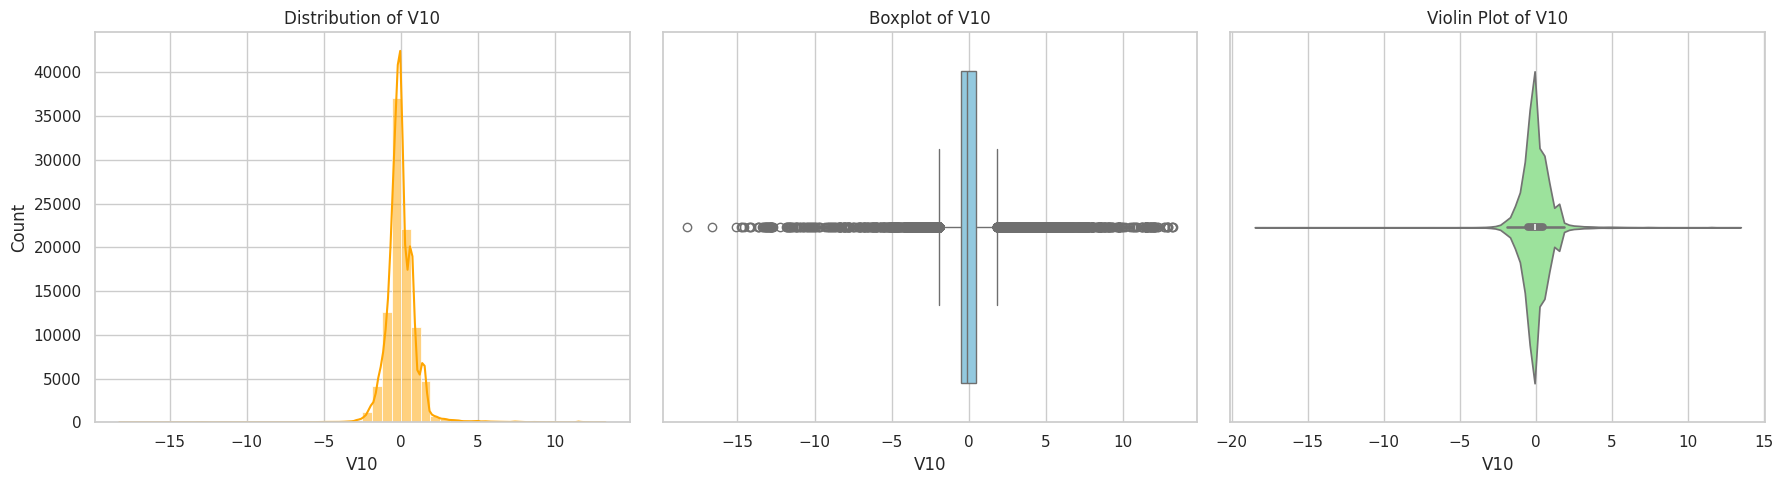

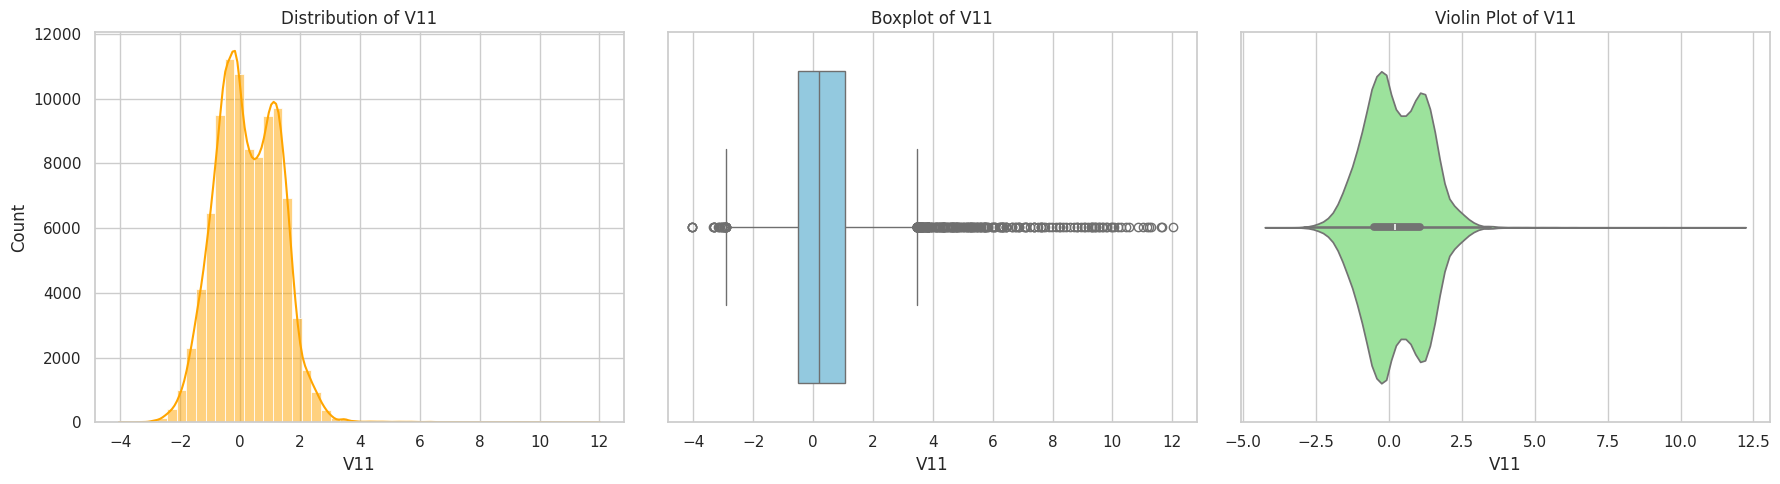

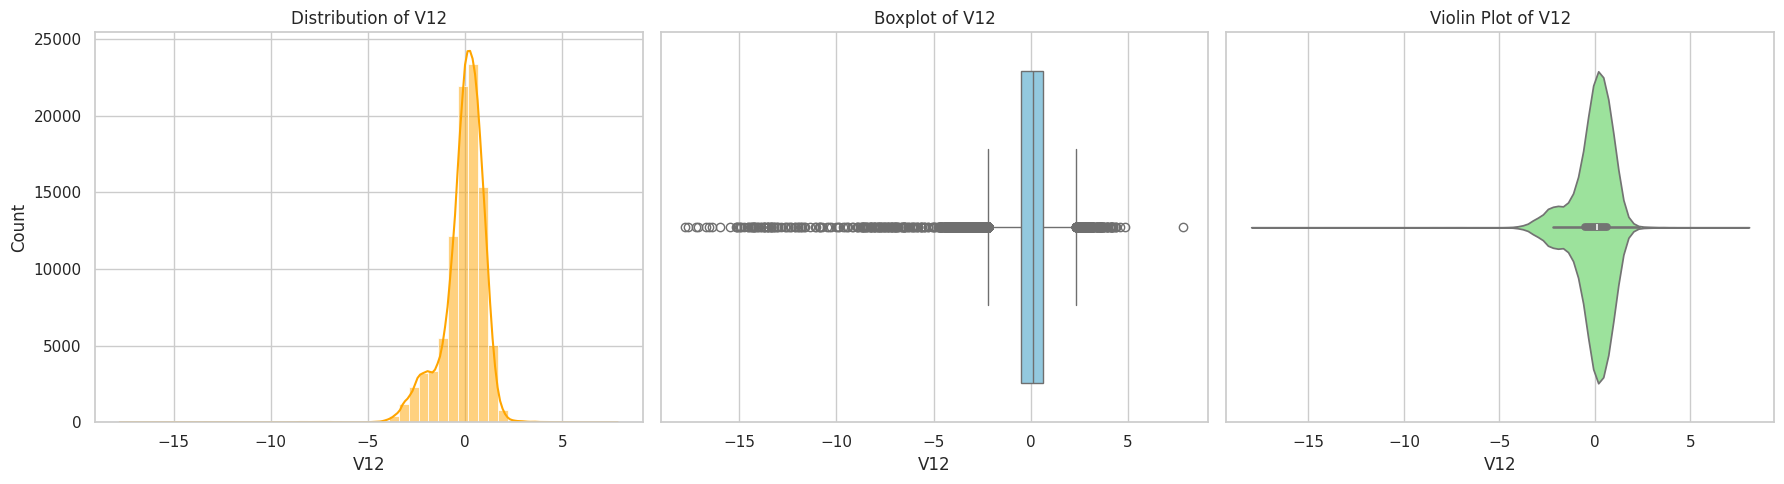

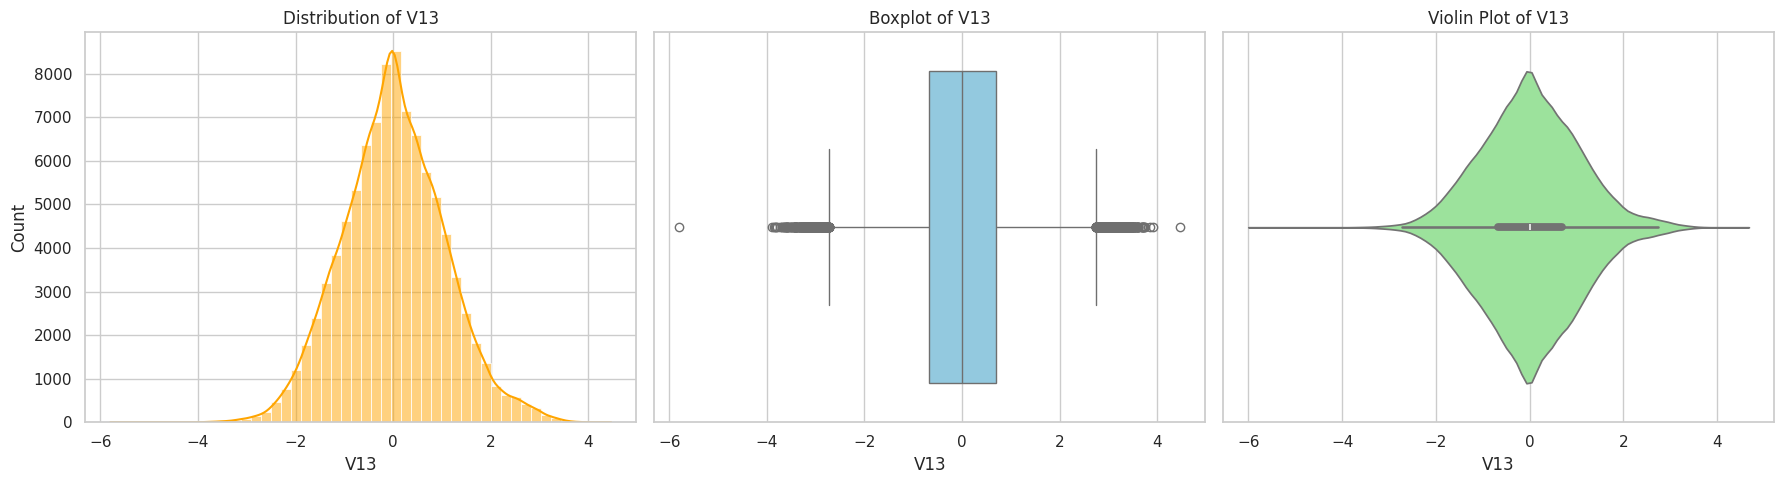

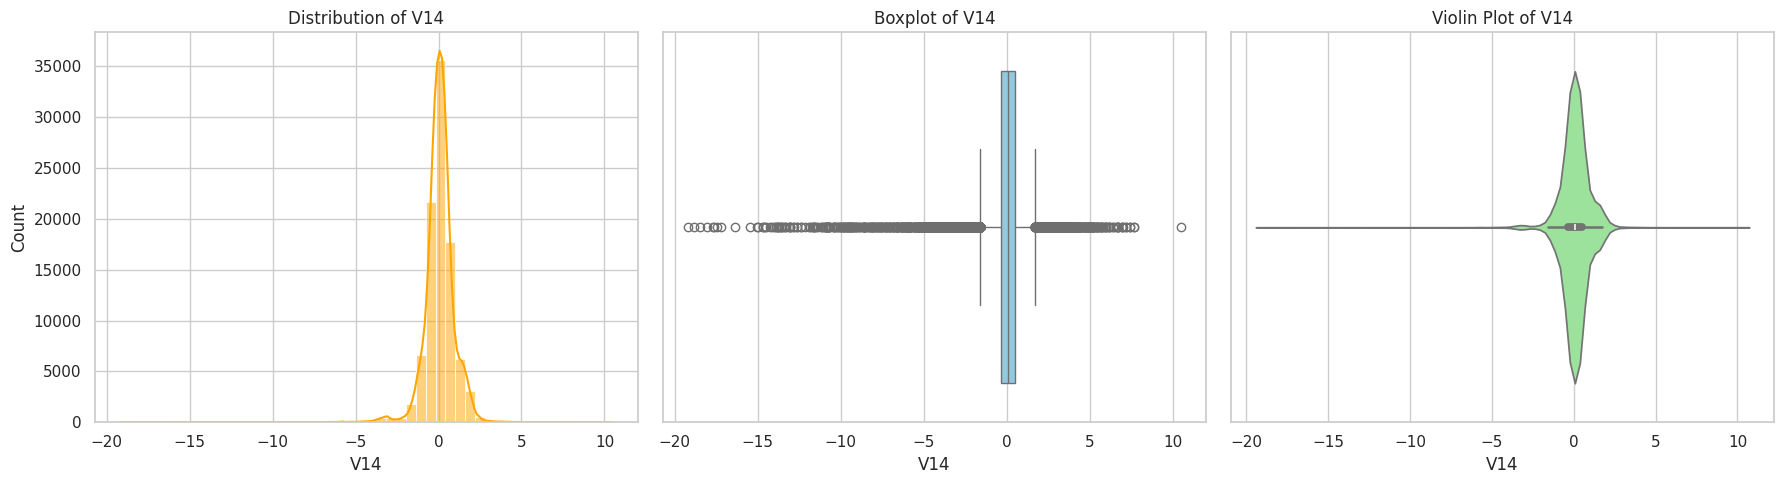

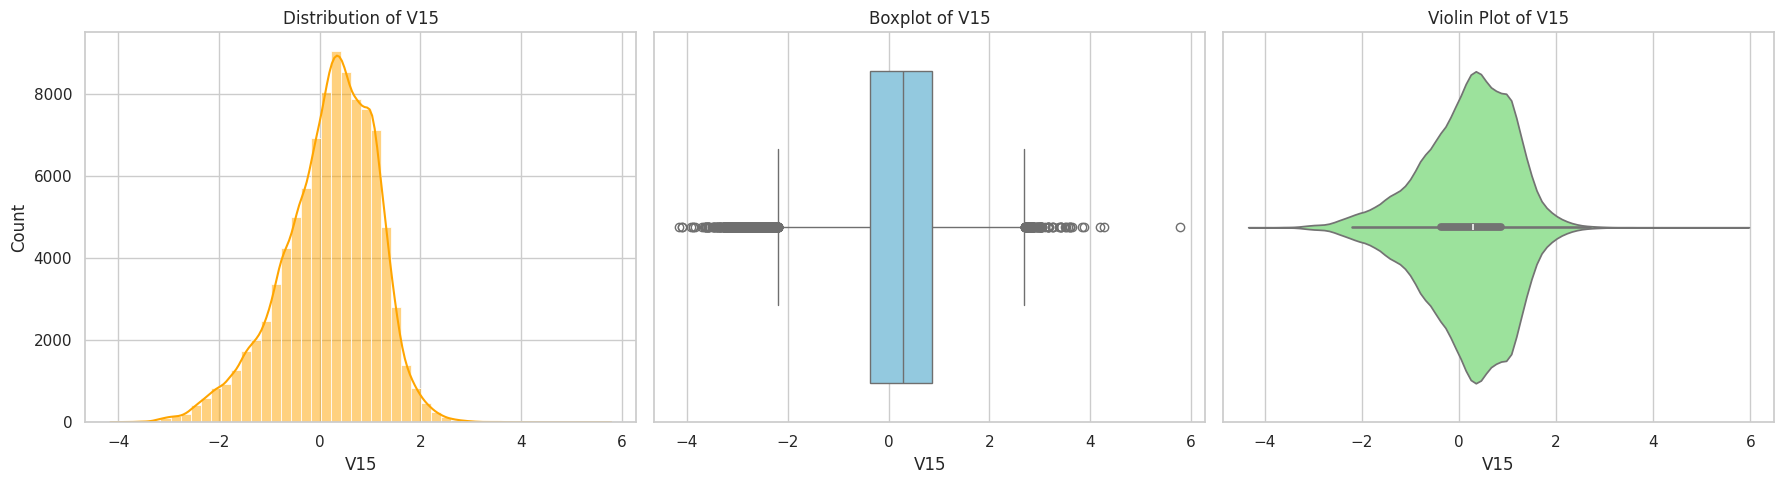

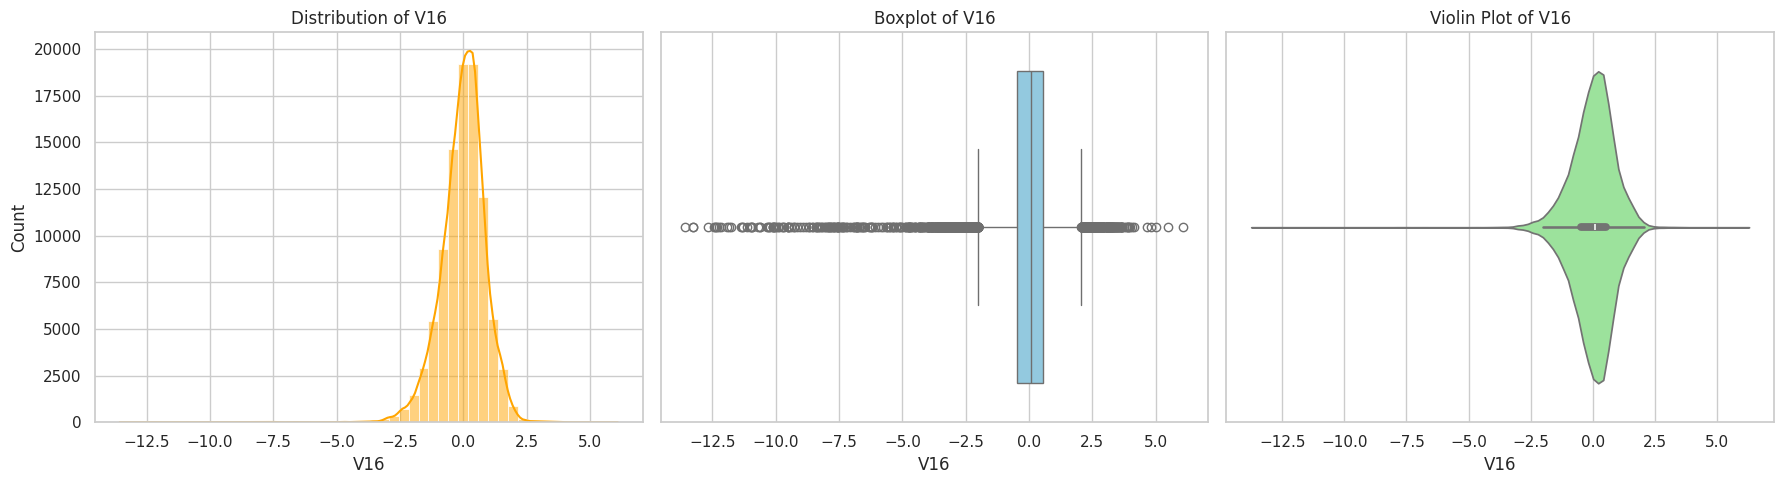

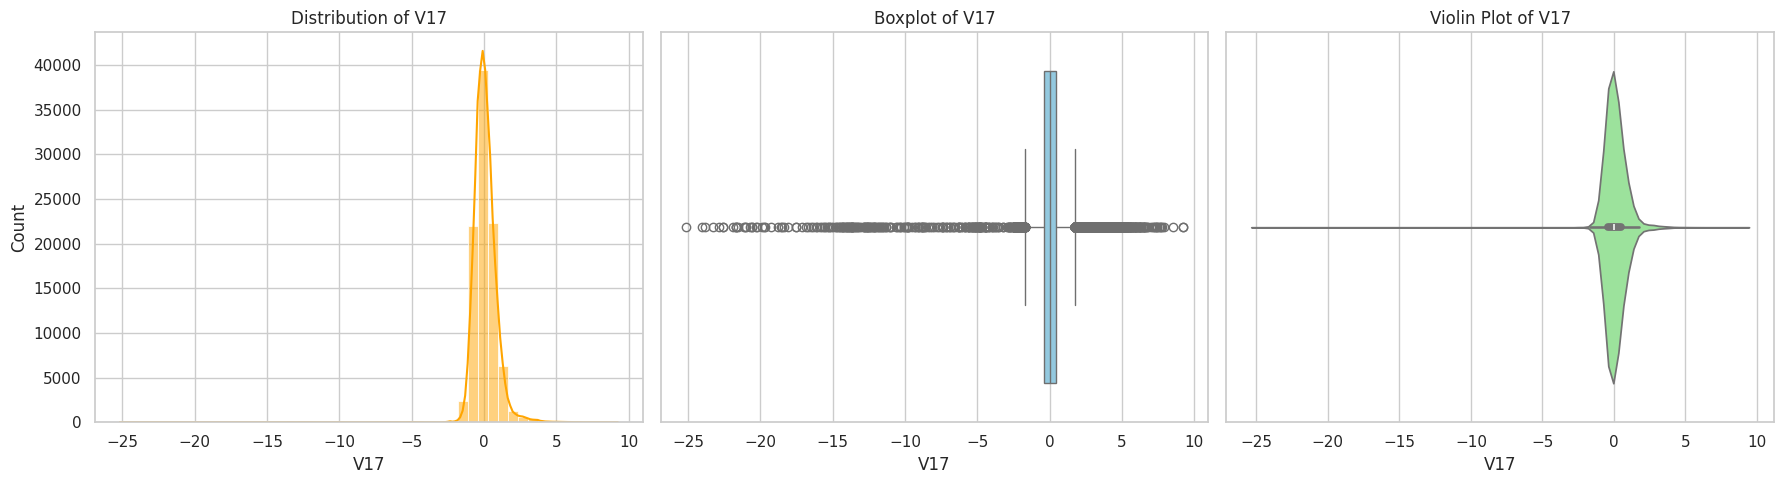

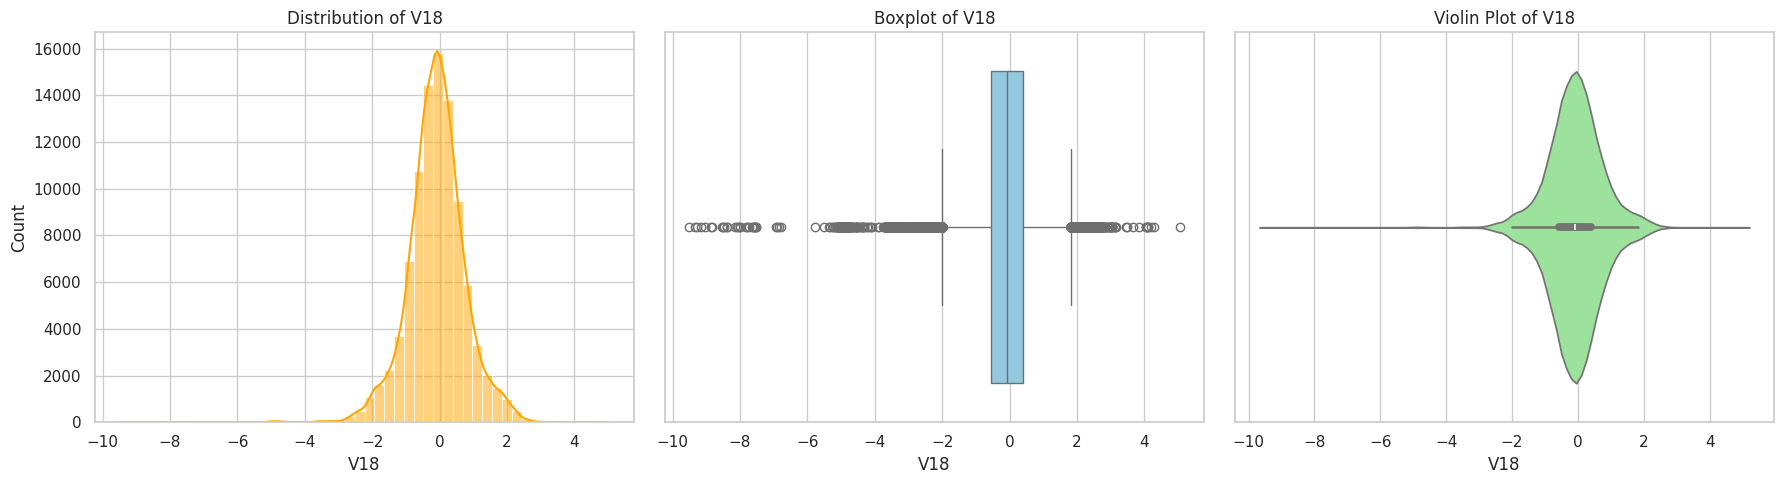

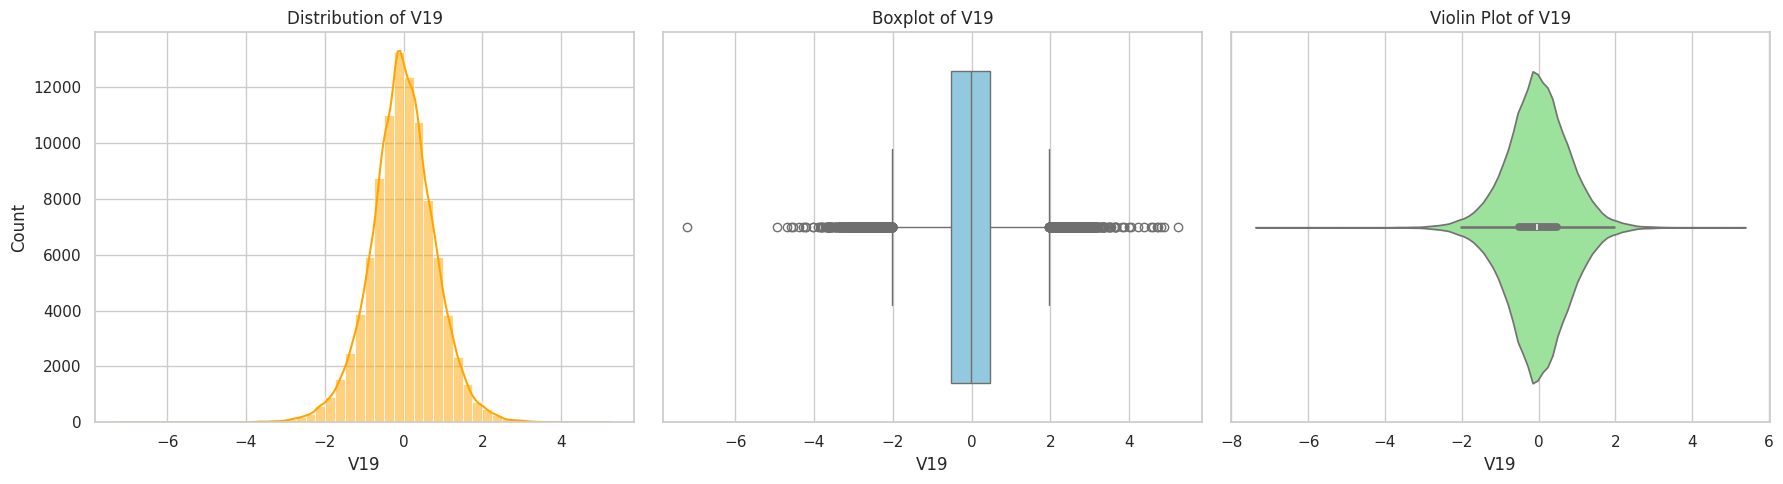

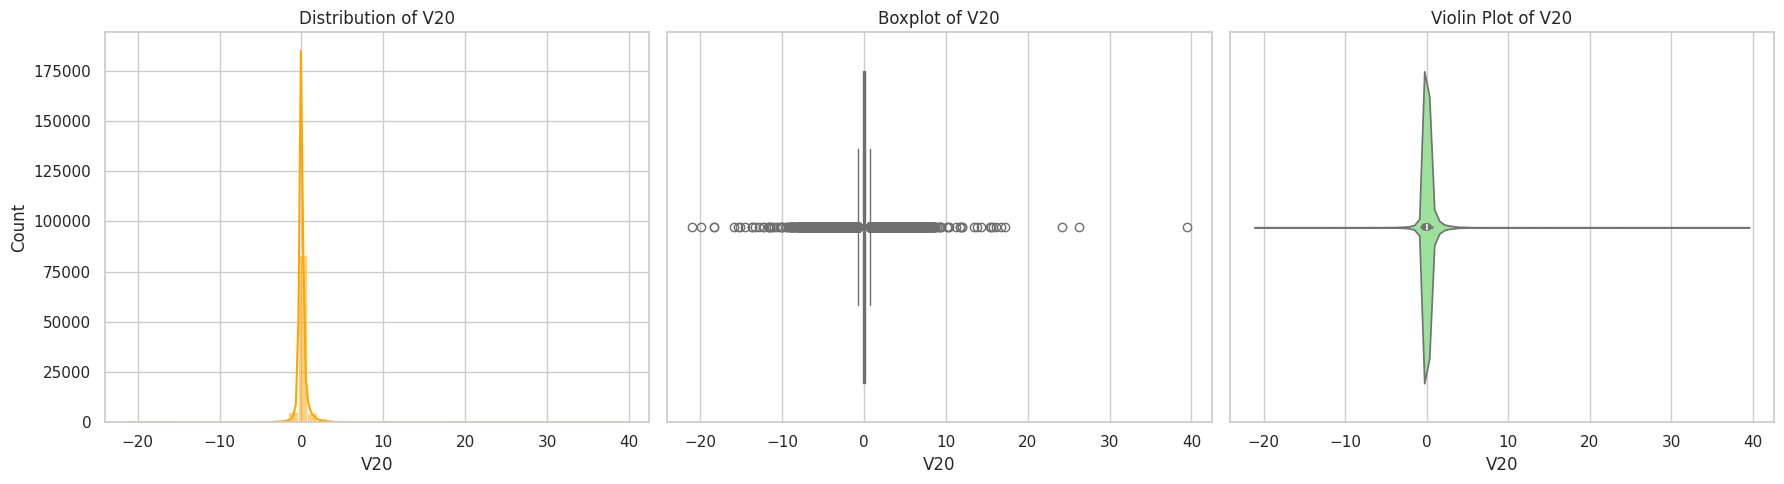

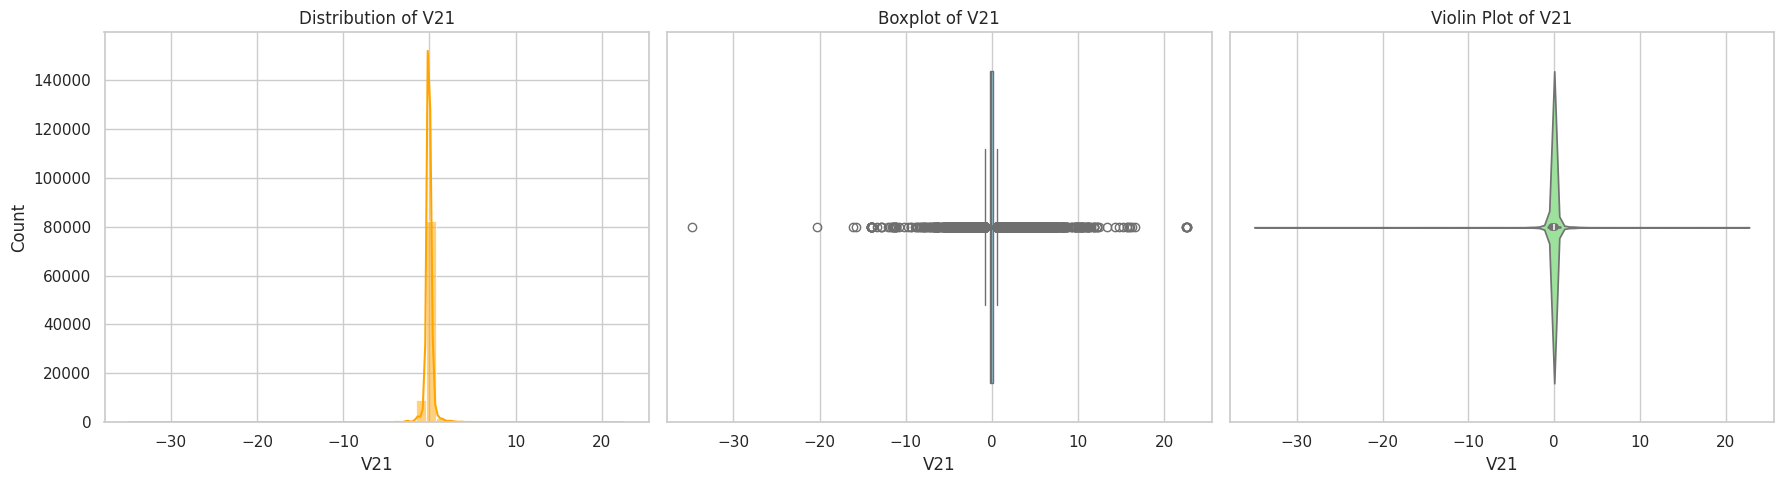

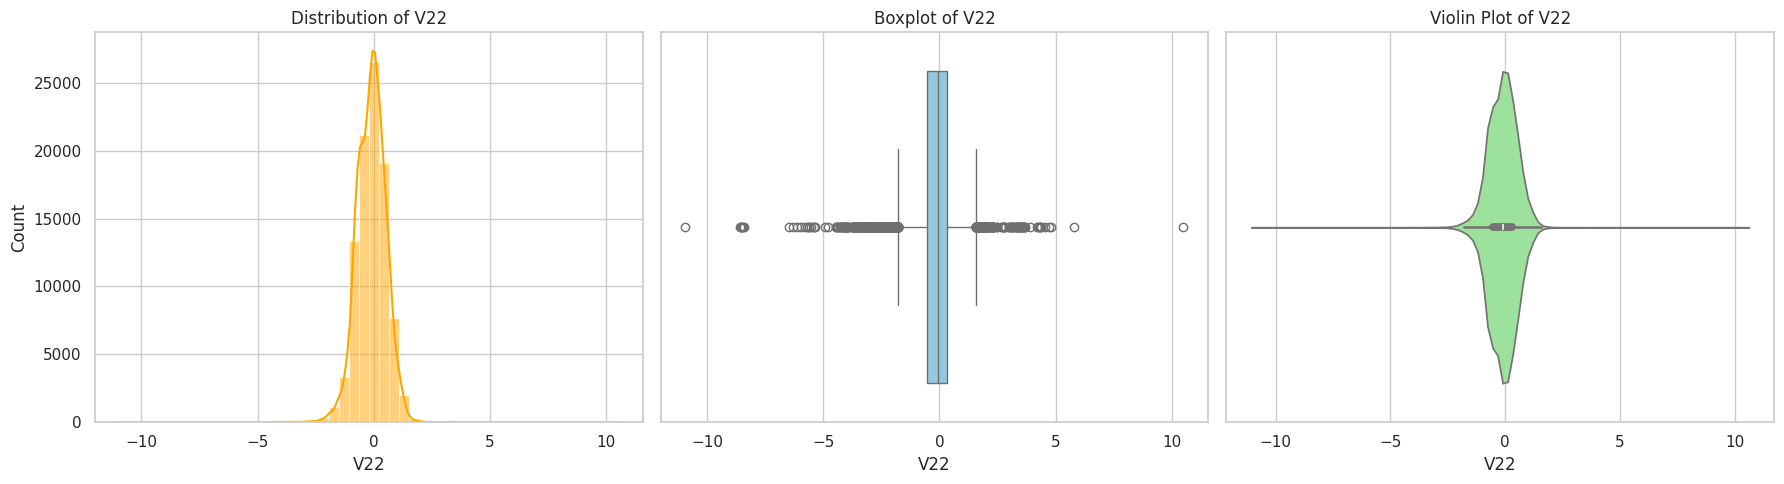

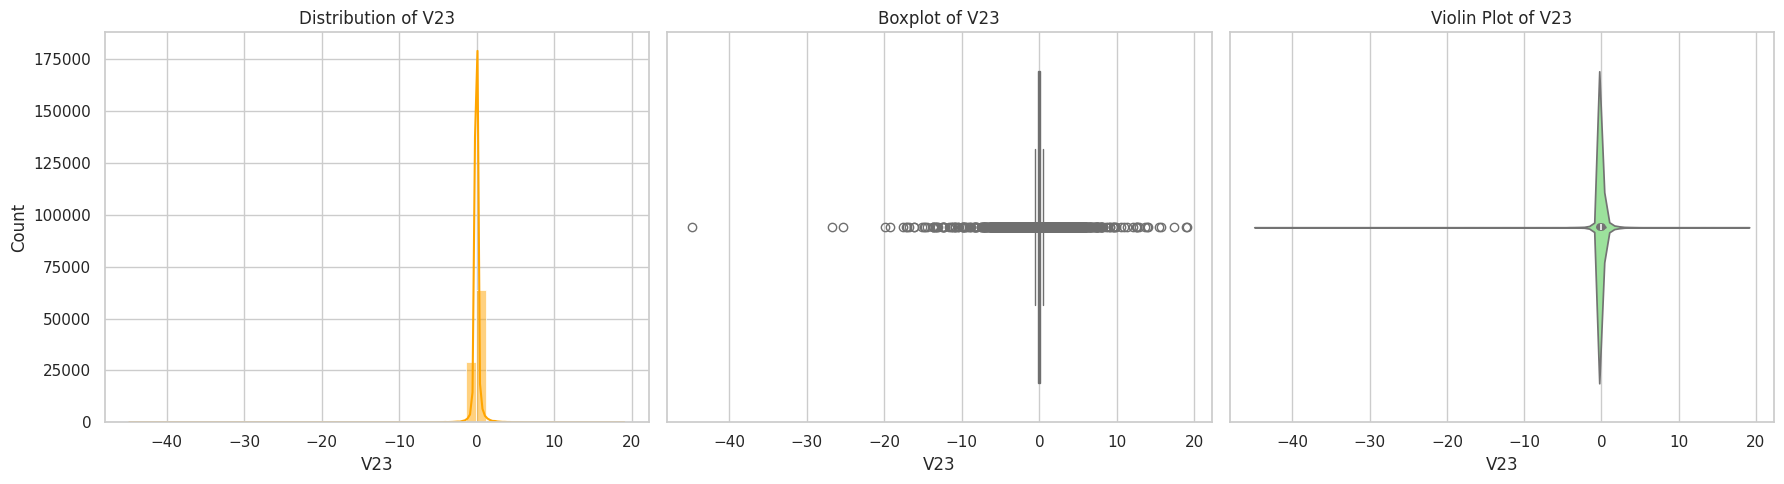

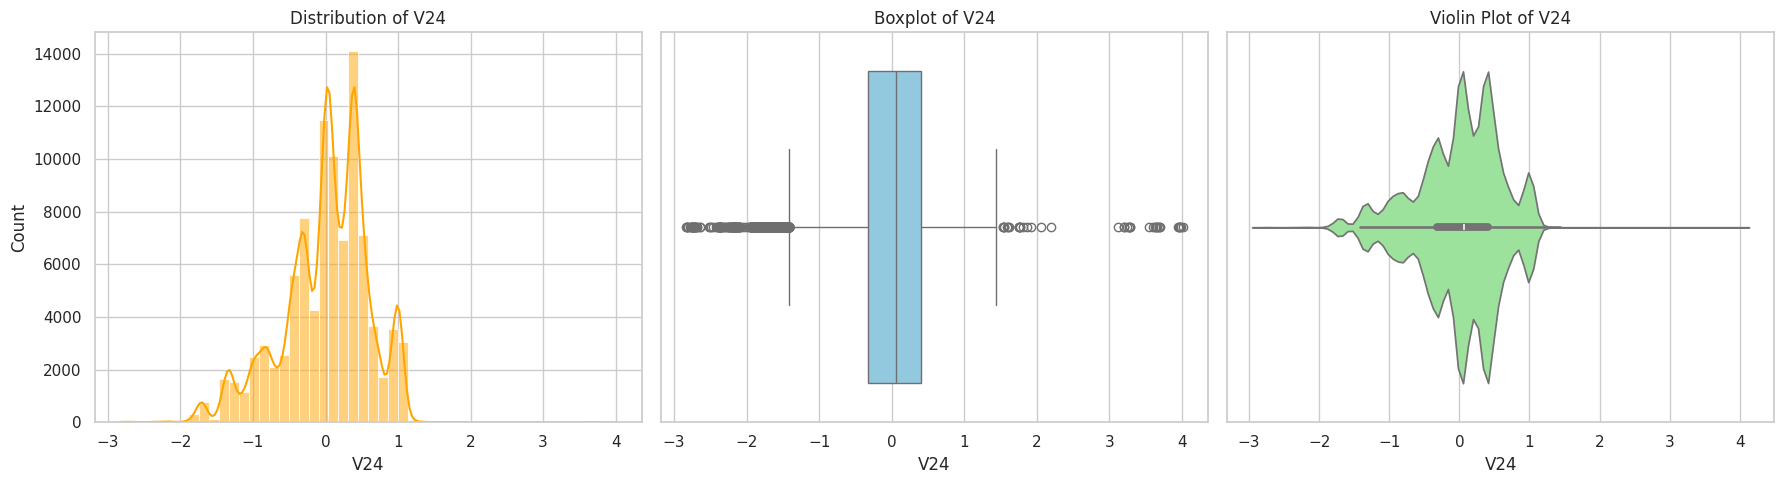

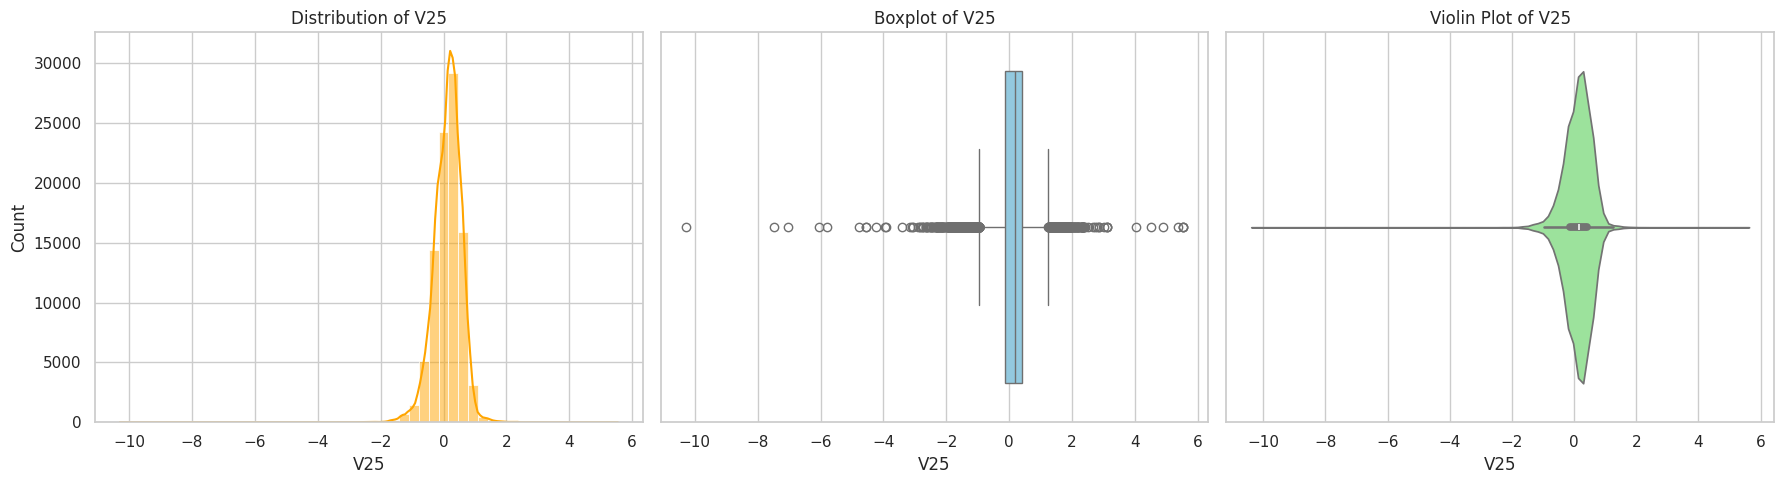

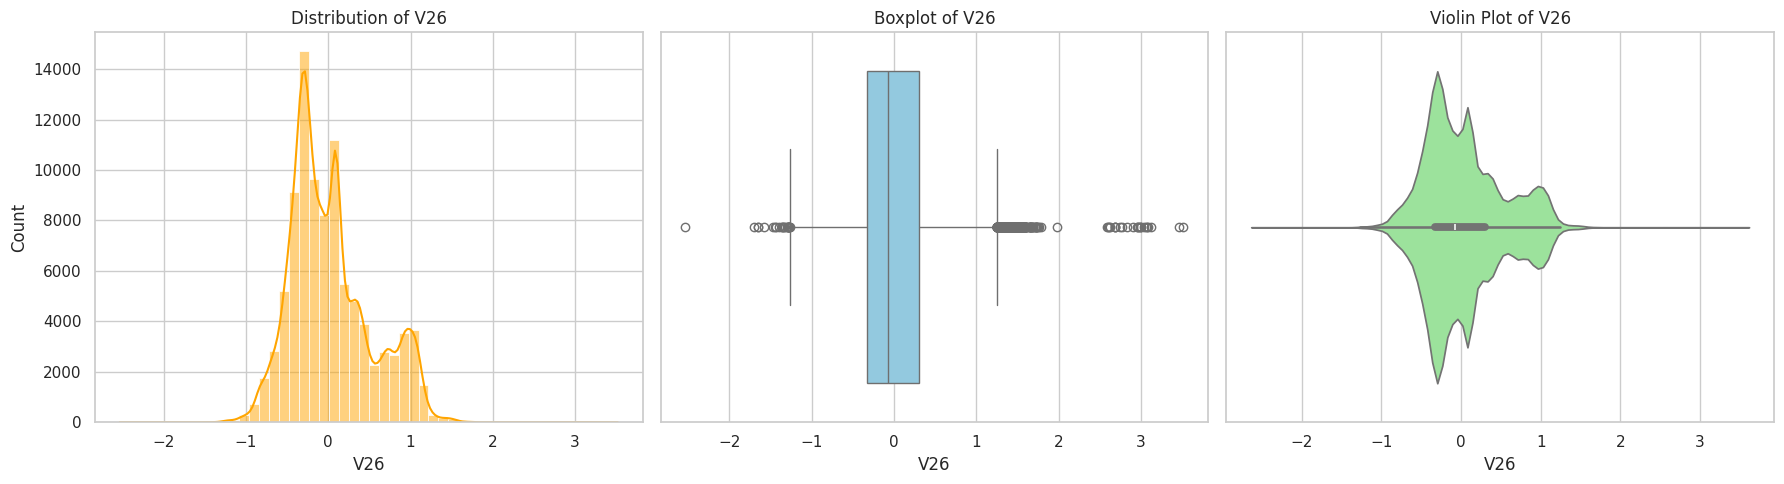

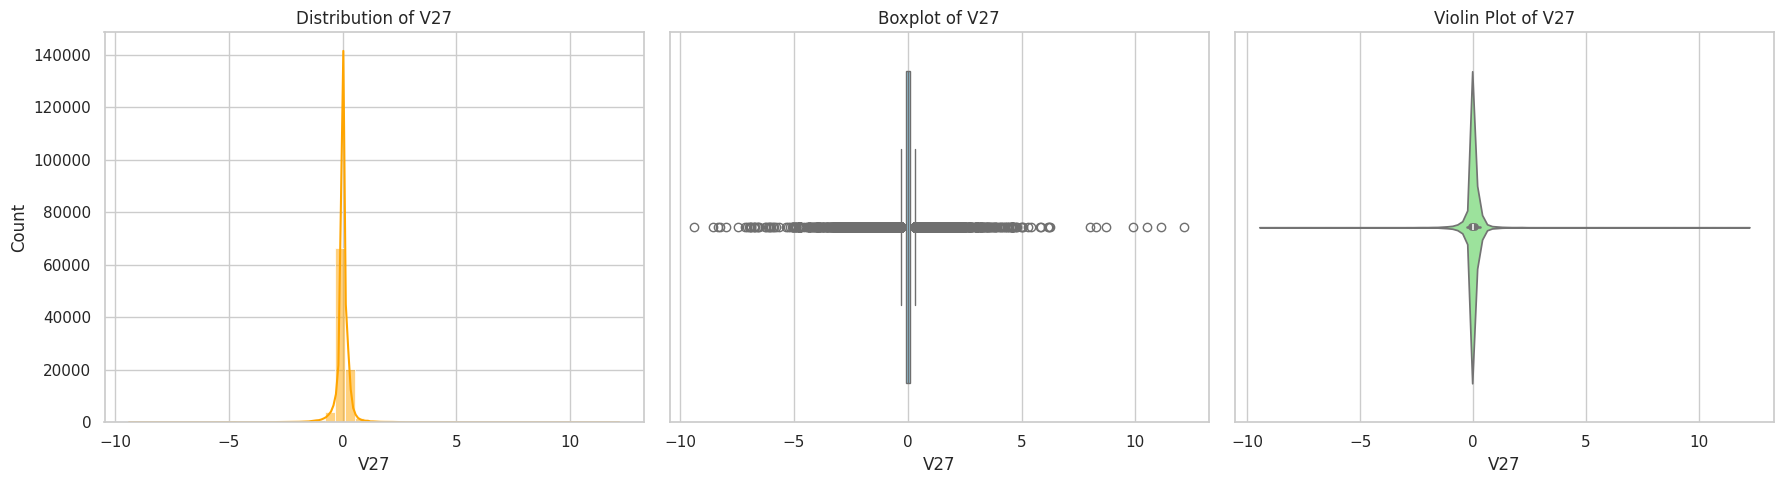

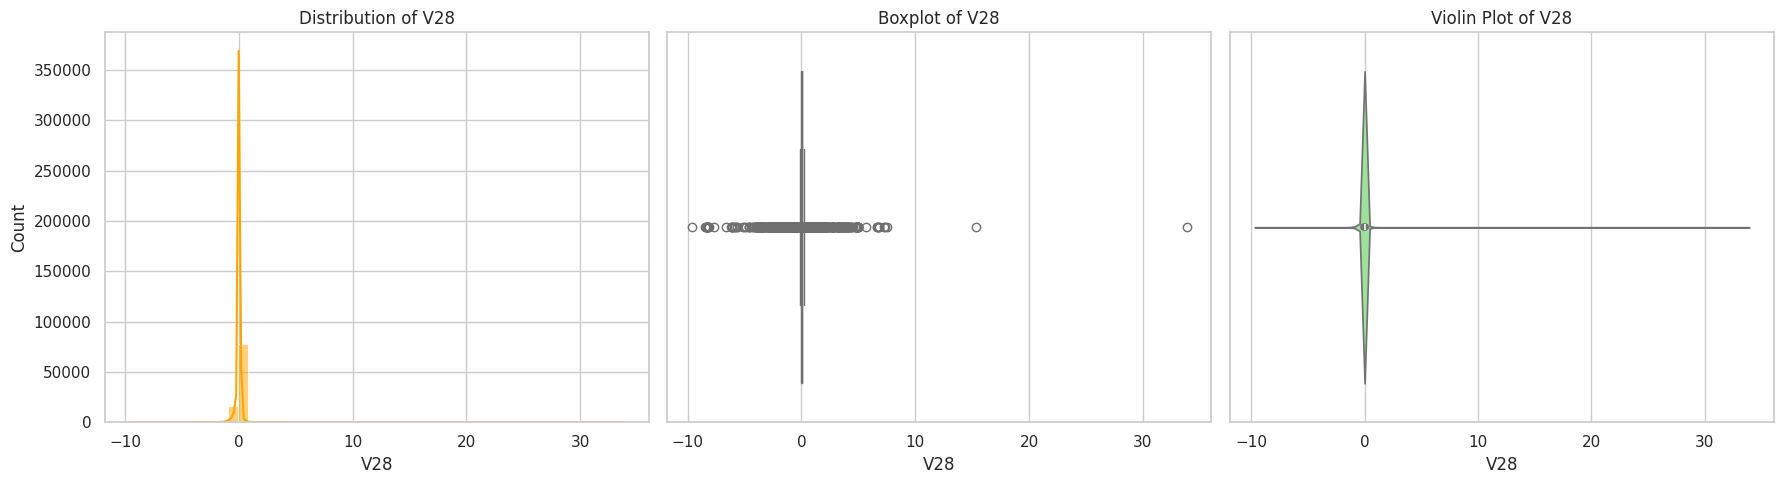

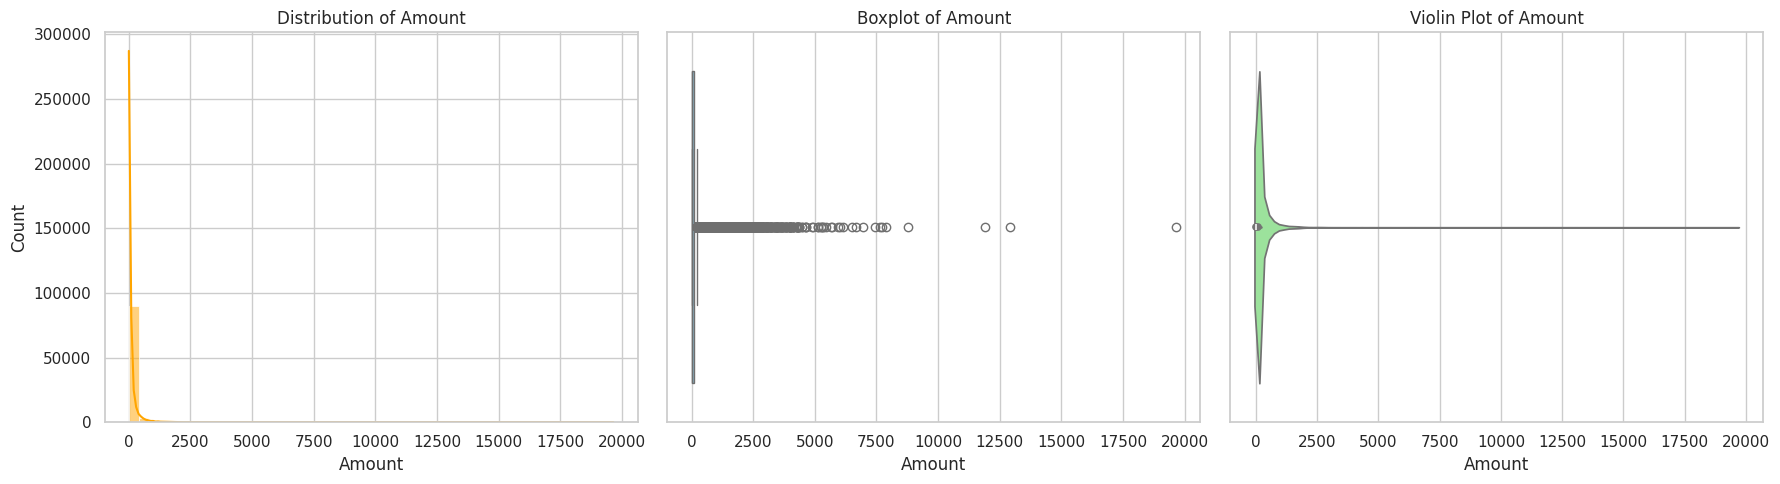

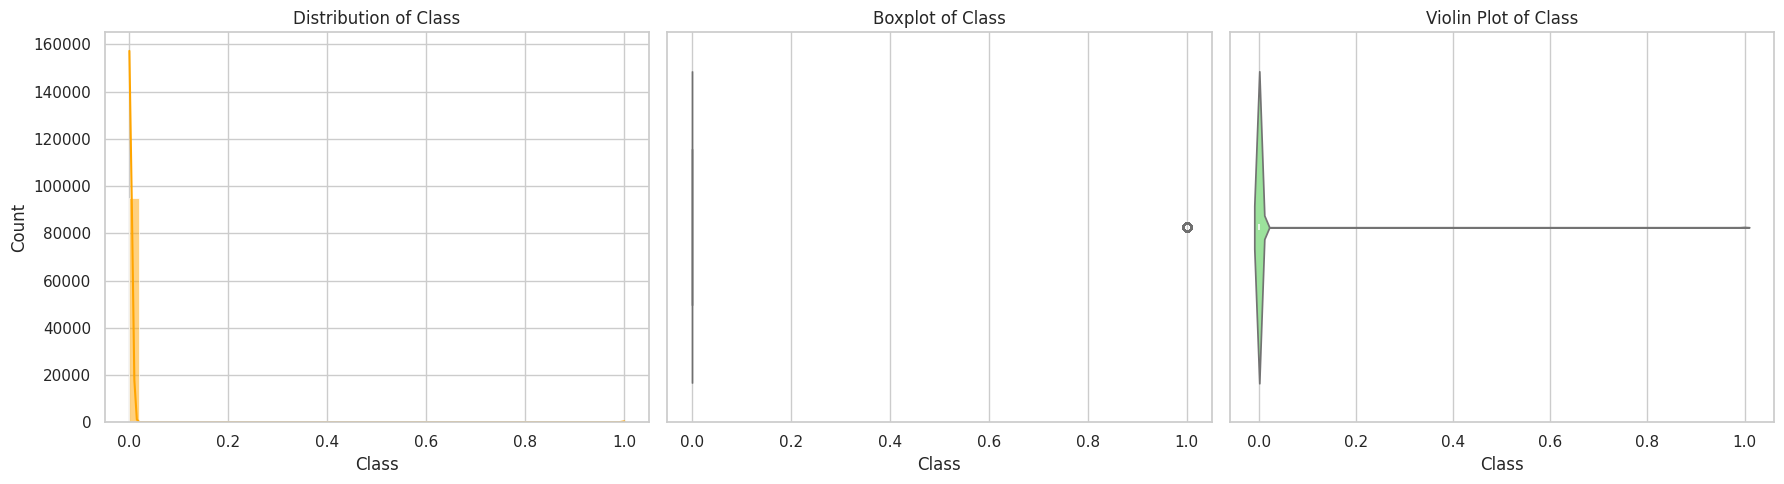

In [3]:
# Your code here
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

def analyze_feature(df, column):
    
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    sns.histplot(df[column], bins=50, kde=True, ax=axes[0], color="orange")
    axes[0].set_title(f"Distribution of {column}")
    
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[1], color="skyblue")
    axes[1].set_title(f"Boxplot of {column}")
    
    # Violinplot
    sns.violinplot(x=df[column], ax=axes[2], color="lightgreen")
    axes[2].set_title(f"Violin Plot of {column}")
    
    plt.tight_layout()
    plt.show()
    
for col in numeric_cols:
    analyze_feature(df, col)

<b>💡 Tip:</b> Utilize statistical libraries like seaborn or matplotlib for streamlined visualization.

<b>❗ Common Mistakes</b>
- Ignoring scale differences between features.
- Misinterpreting skewness or kurtosis values.

## Step 3: Investigate Relationships
- Deploy scatter plots to inspect potential relationships between numerical feature pairs.
- Utilize heatmaps to evaluate feature correlation, focusing on significant correlations.

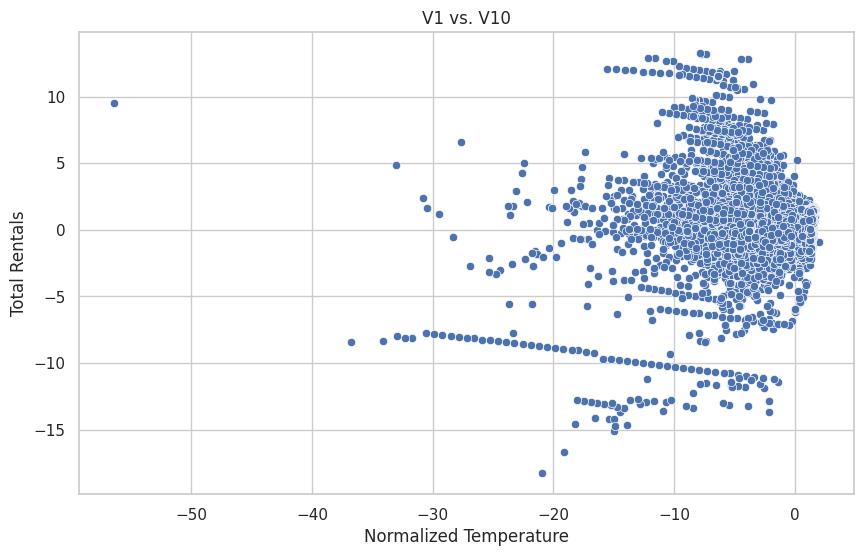

In [4]:
# Your code here
# sns.pairplot(df)
# plt.show()

# for i in numeric_cols:
#     for j in numeric_cols:
#         if i != j:
#             sns.scatterplot(x=i, y=j, data=df)
#             plt.title(f"{i} vs. {j}")
#             plt.xlabel("Normalized Temperature")
#             plt.ylabel("Total Rentals")
#             plt.show()


# import itertools
# def plot_scatter_grid(df, numeric_cols, plots_per_row=3):
#     # Generate unique pairs (i, j) where i < j to avoid repetition
#     unique_pairs = list(itertools.combinations(numeric_cols, 2))
#     total_plots = len(unique_pairs)
#     rows = int(np.ceil(total_plots / plots_per_row))

#     # Create subplots
#     fig, axes = plt.subplots(rows, plots_per_row, figsize=(plots_per_row * 5, rows * 4))
#     axes = axes.flatten()

#     for idx, (x_col, y_col) in enumerate(unique_pairs):
#         sns.scatterplot(x=x_col, y=y_col, data=df, ax=axes[idx], alpha=0.5)
#         axes[idx].set_title(f"{x_col} vs {y_col}")
#         axes[idx].set_xlabel(x_col)
#         axes[idx].set_ylabel(y_col)

#     # Hide unused subplots
#     for ax in axes[total_plots:]:
#         ax.set_visible(False)

#     plt.tight_layout()
#     plt.show()

# plot_scatter_grid(df, numeric_cols, plots_per_row=3)

sns.scatterplot(x="V1", y="V10", data=df)
plt.title(f"V1 vs. V10")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Rentals")
plt.show()

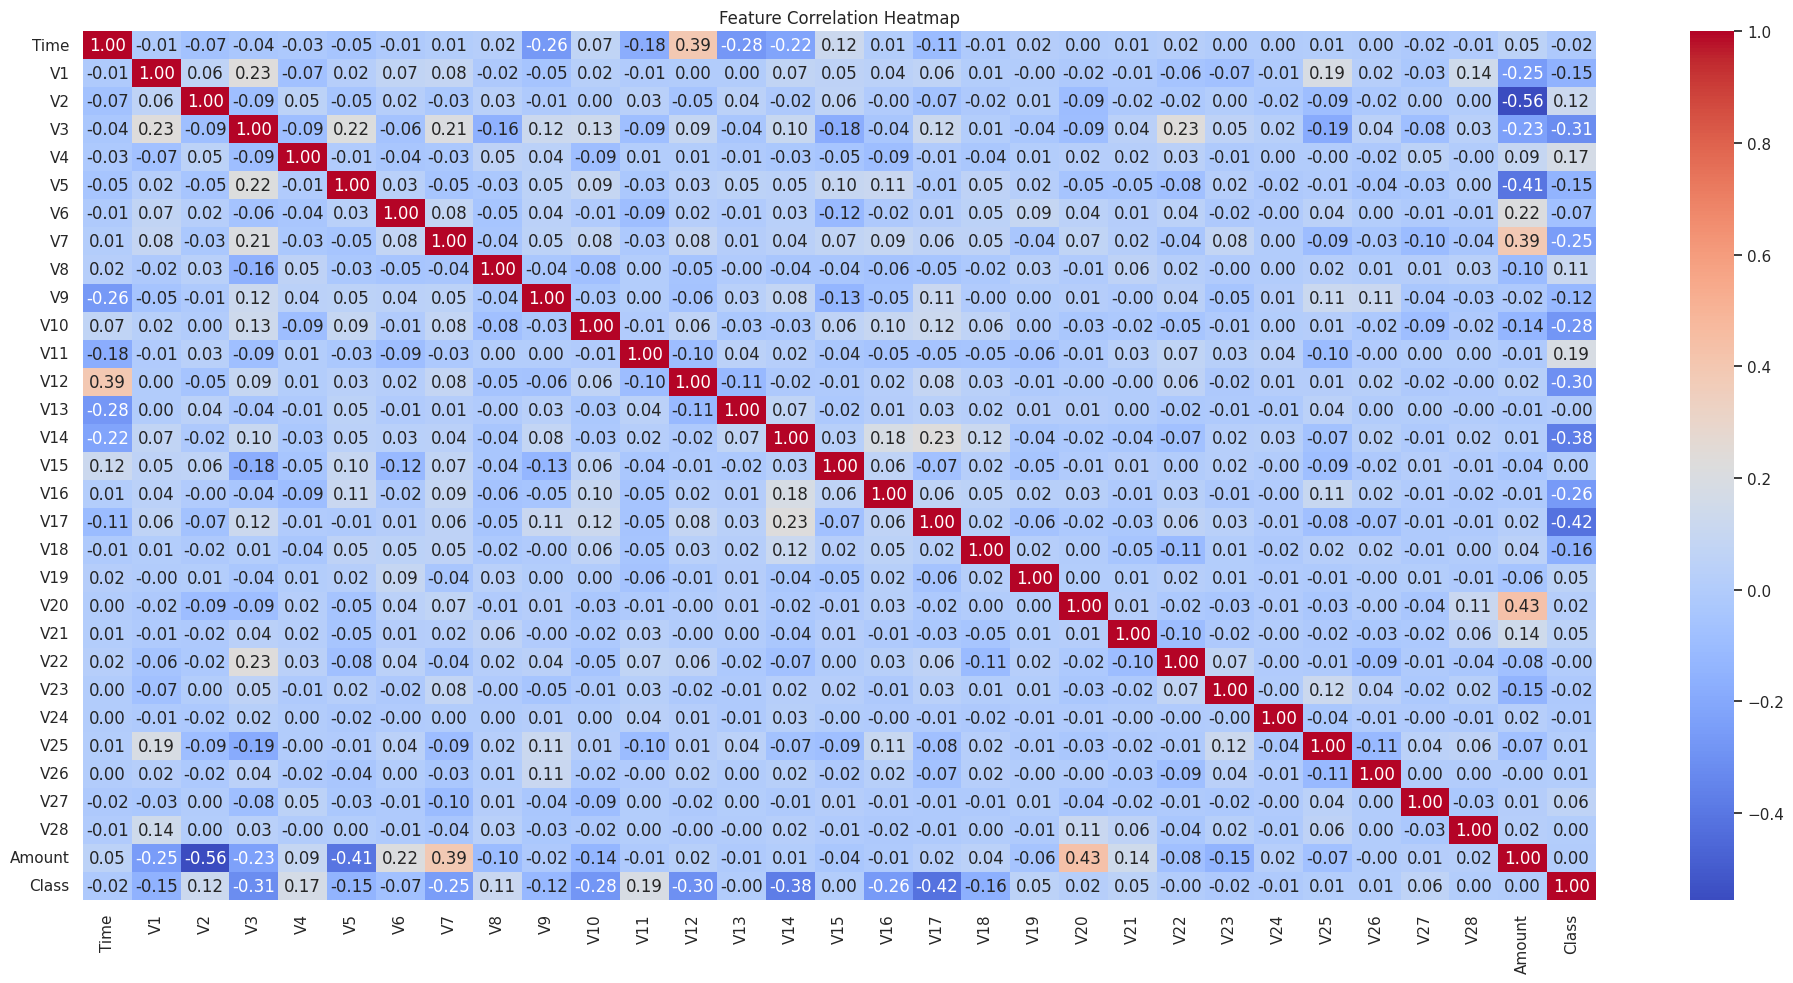

In [5]:
# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

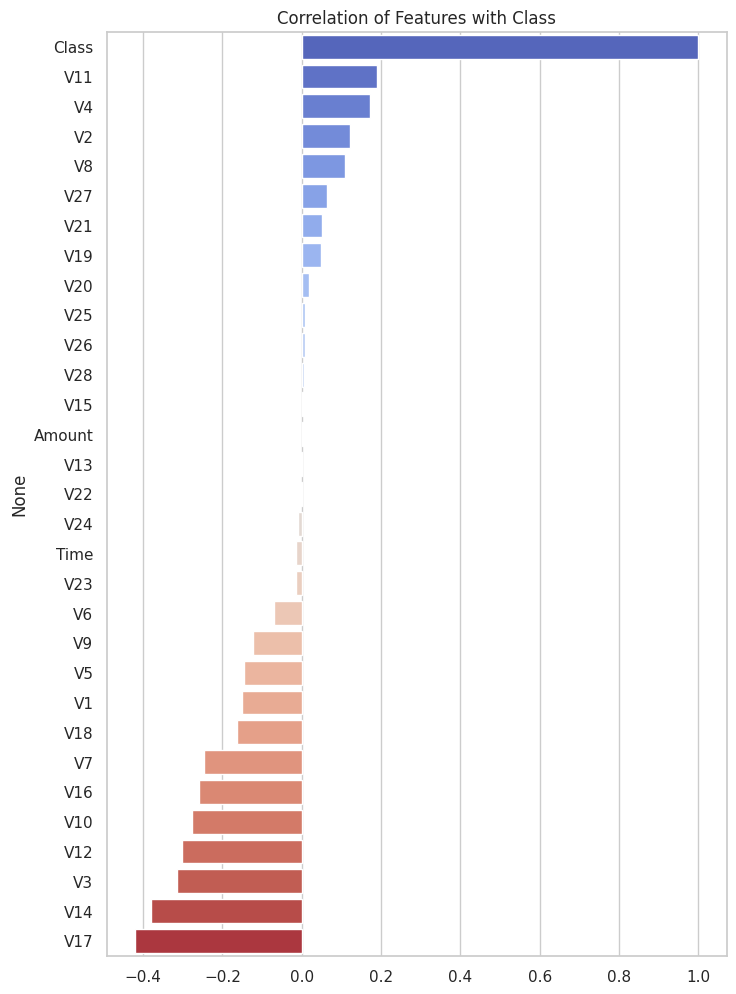

In [29]:
class_corr = corr_matrix["Class"].sort_values(ascending=False)

plt.figure(figsize=(8,12))
sns.barplot(x=class_corr.values, y=class_corr.index, palette="coolwarm")
plt.title("Correlation of Features with Class")
plt.show()

<b>💡 Tip:</b> Look for correlations that might necessitate feature transformation or could suggest interaction effects.

<b>❗ Common Mistakes</b>
- Disregarding non-linear relationships.
- Assuming correlation equals causation without further analysis.

## Step 4: Detect and Analyze Outliers
- Use box plots and statistical methods like Z-scores or IQR to identify and scrutinize outliers.
- Determine whether outliers are data entry errors, genuine values, or indicative of broader issues.

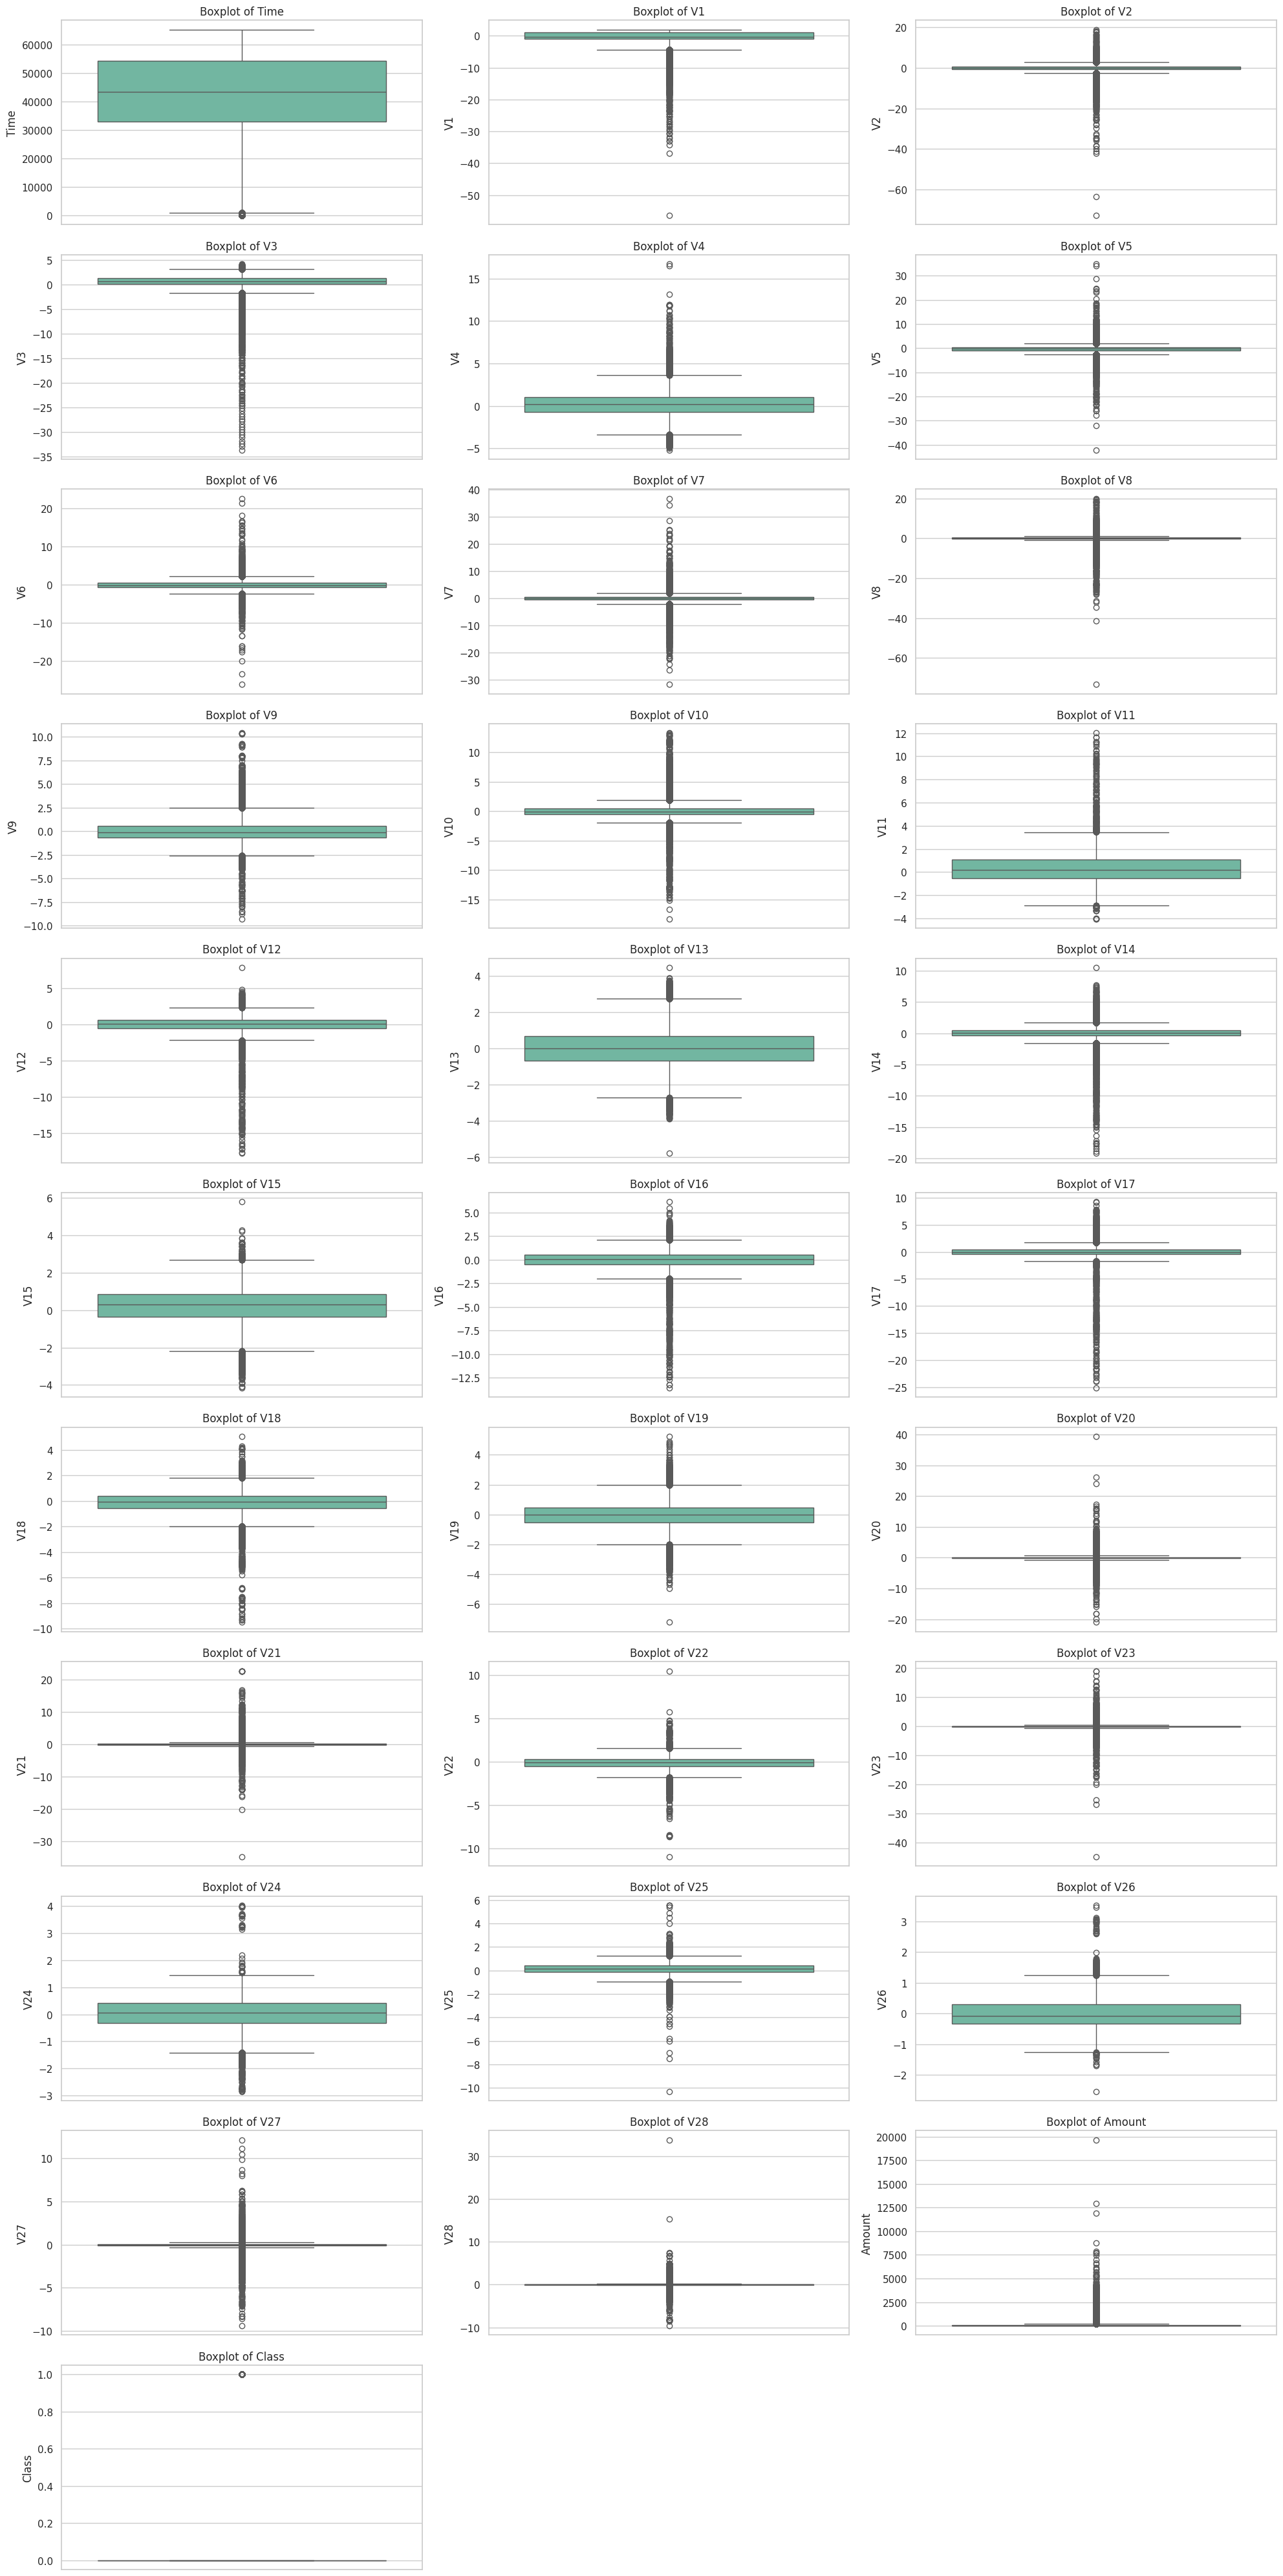

In [6]:
# Your code here

plt.figure(figsize=(20, 40))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i)  
    sns.boxplot(data=df, y=col, palette="Set2")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [7]:
def detect_outliers_all_columns(df, method="iqr", threshold=3.0):
    """
    Detect outliers in all numerical columns using Z-score or IQR.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        method (str): "zscore" or "iqr"
        threshold (float): Z-score threshold or IQR multiplier
    
    Returns:
        pd.DataFrame: Summary of outliers per column
    """
    results = []
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        series = df[col]
        if method == "zscore":
            # Drop NaNs and align index
            valid_series = series.dropna()
            z_scores = zscore(valid_series)
            outlier_mask = (z_scores > threshold) | (z_scores < -threshold)
            outlier_indices = valid_series.index[outlier_mask].tolist()
        elif method == "iqr":
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            outlier_mask = (series < lower_bound) | (series > upper_bound)
            outlier_indices = series.index[outlier_mask].tolist()
        else:
            raise ValueError("Method must be 'zscore' or 'iqr'")
        
        results.append({
            "Column": col,
            "Outlier Count": len(outlier_indices),
#             "Outlier Indices": outlier_indices
        })

    return pd.DataFrame(results)

# Detect using IQR
iqr_outliers = detect_outliers_all_columns(df, method="iqr", threshold=1.5)
iqr_outliers

,Column,Outlier Count
0,Time,1140
1,V1,2572
2,V2,5184
3,V3,3037
4,V4,1127
5,V5,5823
6,V6,7766
7,V7,3480
8,V8,8467
9,V9,2811


In [8]:
outlier_df = detect_outliers_all_columns(df, method="zscore", threshold=3.0)
display(outlier_df)

,Column,Outlier Count
0,Time,0
1,V1,1390
2,V2,1569
3,V3,939
4,V4,509
5,V5,1116
6,V6,1531
7,V7,1234
8,V8,1369
9,V9,743


<b>💡 Tip:</b> Explore transforming or imputing outliers if they distort the dataset analysis.

<b>❗ Common Mistakes</b>
- Automatically removing outliers without investigating their context.
- Underestimating the impact of outliers on down-the-line modeling.

## Step 5: Create a Summary Report
- Synthesize your findings into a digestible report highlighting key insights—distributions, relationships, and outliers.
- Emphasize any patterns or anomalies that could impact future ML modeling.

## Bivariate Analysis

In [10]:
# Time-derived proxies (Time = seconds-from-start, not real timestamps)

df['Hour_from_start_mod24'] = ((df['Time'] // 3600) % 24).astype(int)
df['is_night_proxy'] = df['Hour_from_start_mod24'].isin([22,23,0,1,2,3,4,5]).astype(int)
df['is_business_hours_proxy'] = df['Hour_from_start_mod24'].between(9,17).astype(int)

df['_log_amount'] = np.log1p(df['Amount'])


features = [c for c in df.columns if c.startswith("V")] + [
    'Amount','_log_amount',
    'Hour_from_start_mod24','is_night_proxy','is_business_hours_proxy'
]
target = "Class"

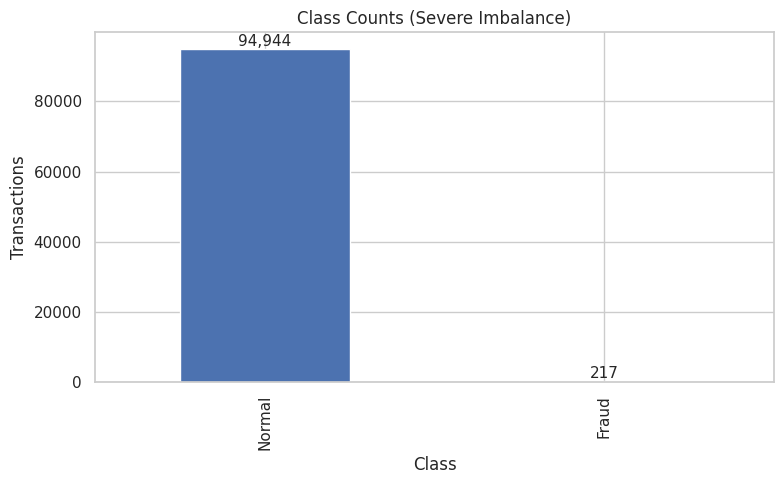

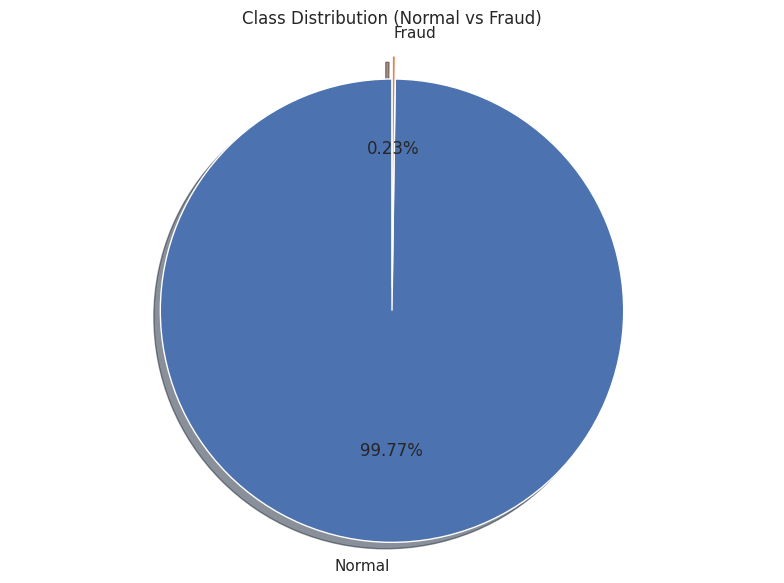

In [11]:
counts = df['Class'].value_counts().rename({0:'Normal', 1:'Fraud'})
fig, ax = plt.subplots(figsize=(8,5))
counts.plot(kind='bar', ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=11)
ax.set_title('Class Counts (Severe Imbalance)')
ax.set_ylabel('Transactions'); ax.set_xlabel('Class')
plt.tight_layout()
plt.show()

# pie chart
fig, ax = plt.subplots(figsize=(8,6))
ax.pie(counts.values, labels=counts.index, autopct='%1.2f%%', startangle=90, explode=[0,0.1], shadow=True)
ax.set_title('Class Distribution (Normal vs Fraud)')
ax.axis('equal')
plt.tight_layout()
plt.show()

In [13]:
df.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour_from_start_mod24,is_night_proxy,is_business_hours_proxy,_log_amount
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0,0,1,0,5.014760
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0,0,1,0,1.305626


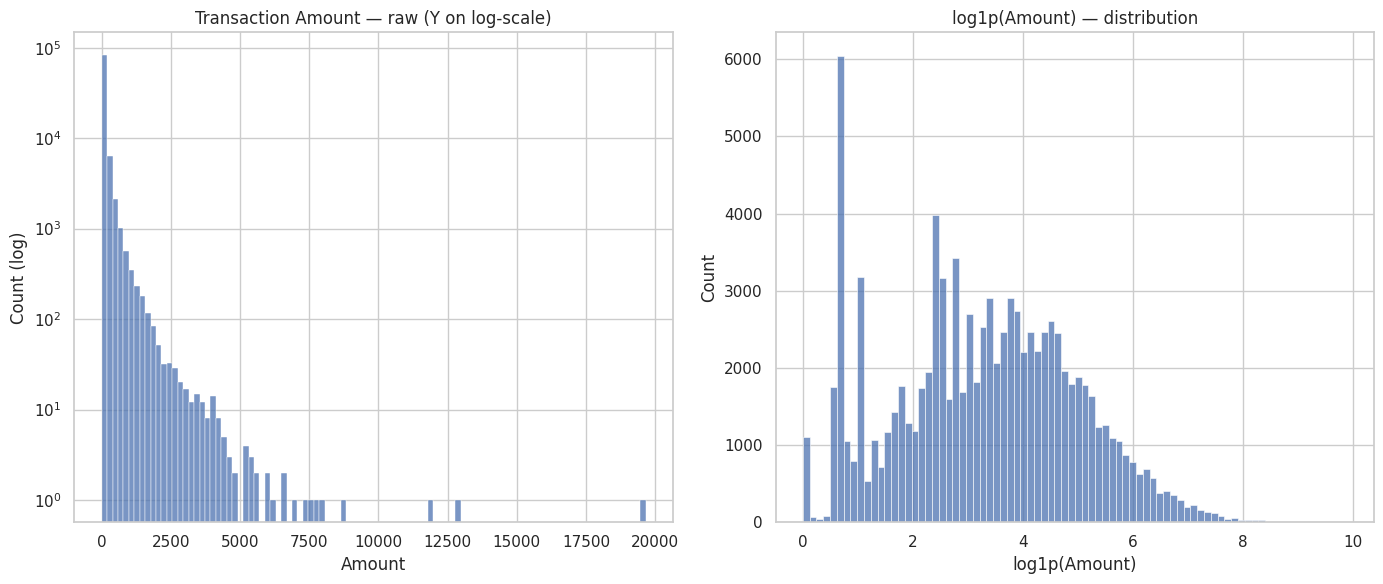

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw amount, log-scaled Y
sns.histplot(df["Amount"], bins=100, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Transaction Amount — raw (Y on log-scale)")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count (log)")

# Log-transformed feature on X
sns.histplot(df["_log_amount"], bins=80, ax=axes[1])
axes[1].set_title("log1p(Amount) — distribution")
axes[1].set_xlabel("log1p(Amount)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

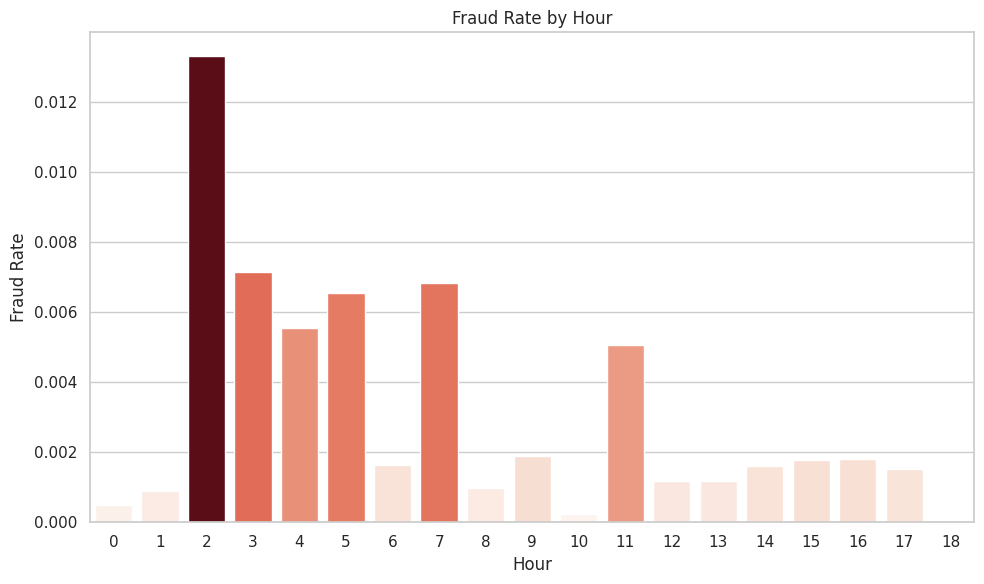

In [17]:
fraud_by_hour = df.groupby("Hour_from_start_mod24")["Class"].mean()

cmap = sns.color_palette("Reds", as_cmap=True)
vals = (fraud_by_hour / fraud_by_hour.max()).values
pal = [cmap(v) for v in vals]

sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, palette=pal)
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

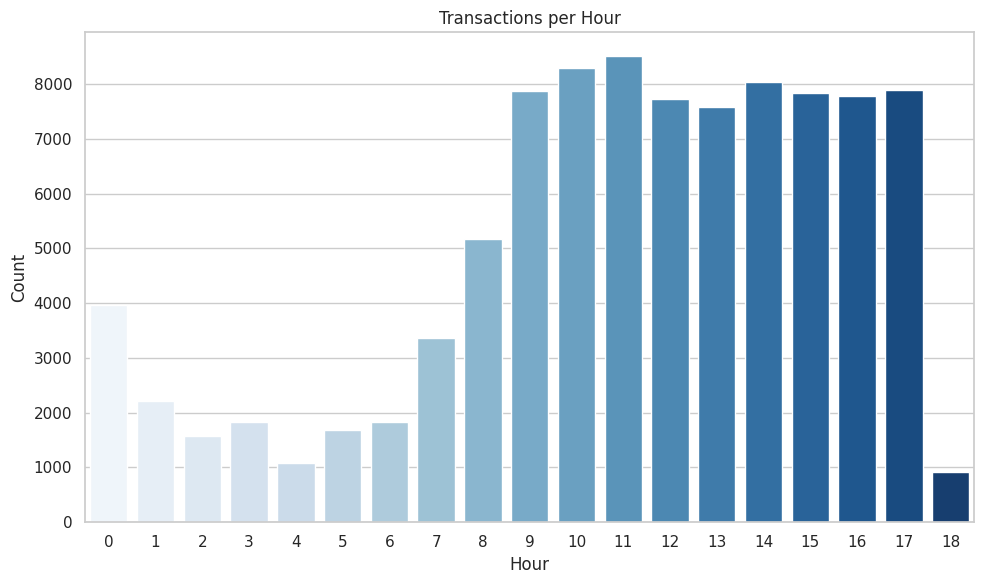

In [18]:
tx_by_hour = df.groupby("Hour_from_start_mod24")[target].count()
sns.barplot(x=tx_by_hour.index, y=tx_by_hour.values, palette='Blues')
plt.title("Transactions per Hour")
plt.xlabel('Hour')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

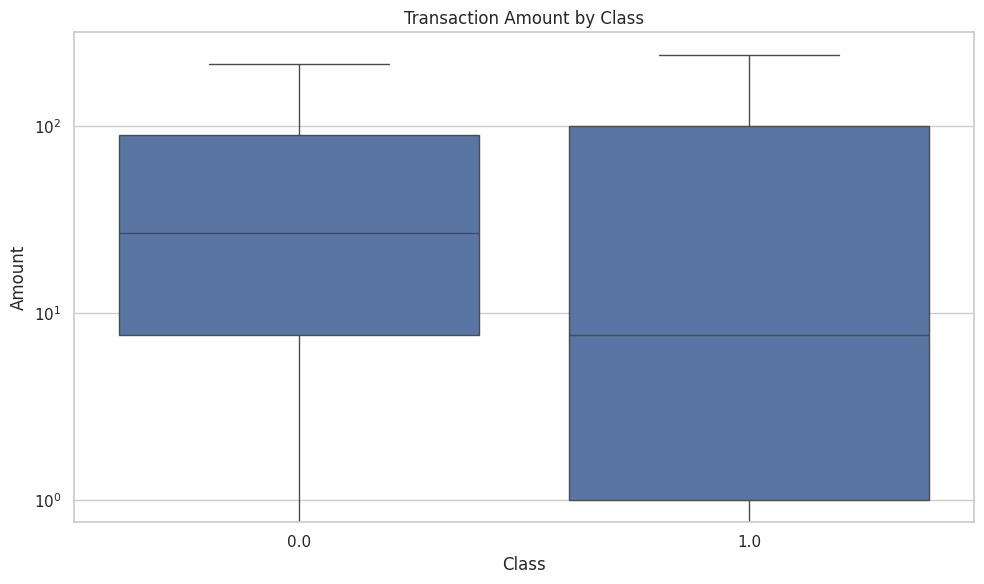

In [19]:
sns.boxplot(x= "Class", y="Amount" , data=df , showfliers=False)
plt.yscale("log")
plt.title("Transaction Amount by Class")
plt.tight_layout()
plt.show()

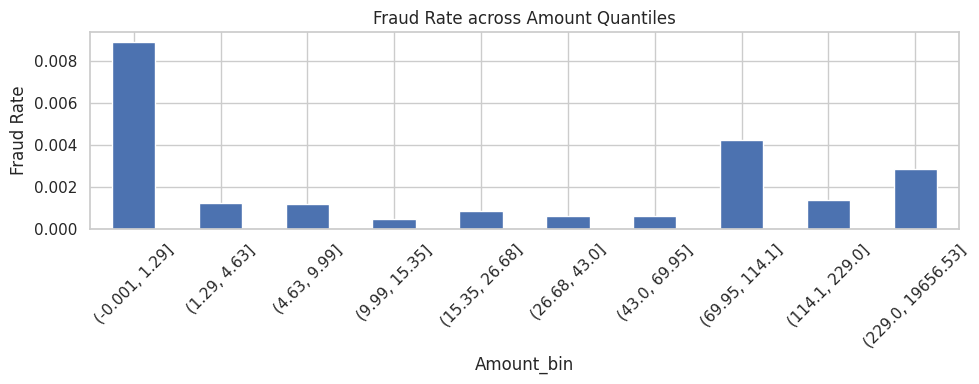

In [20]:
df["Amount_bin"] = pd.qcut(df["Amount"], q=10, duplicates="drop")
fraud_rate_bins = df.groupby("Amount_bin")["Class"].mean()
fraud_rate_bins.plot(kind="bar", figsize=(10,4))
plt.title("Fraud Rate across Amount Quantiles")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

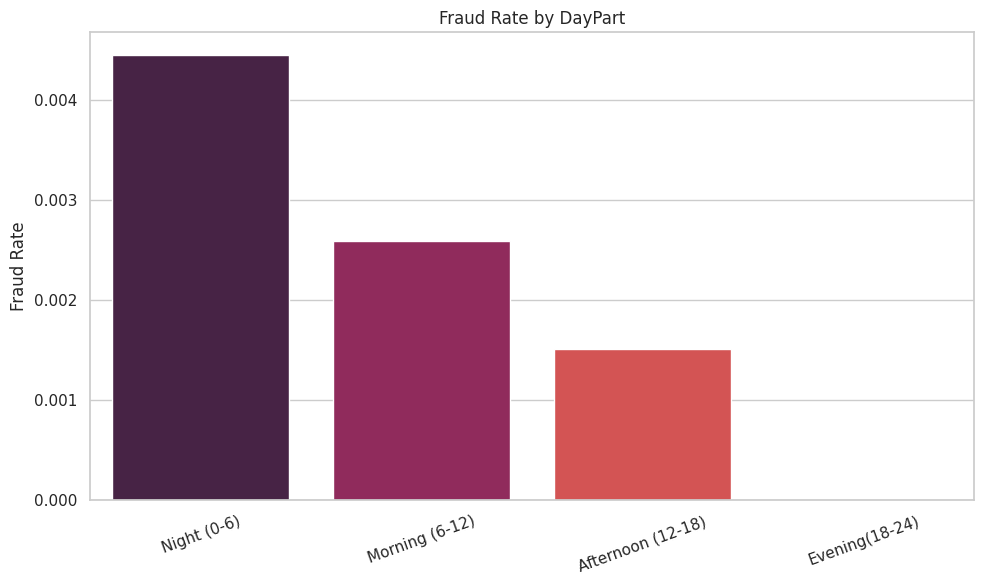

In [21]:
bins   = [0,6,12,18,24]
labels = ["Night (0-6)", "Morning (6-12)", "Afternoon (12-18)", "Evening(18-24)"]
df["DayPart"] = pd.cut(df["Hour_from_start_mod24"], bins=bins, labels=labels, right=False, include_lowest=True)


fraud_by_part  = df.groupby("DayPart")["Class"].mean().reindex(labels)

sns.barplot(x=fraud_by_part.index, y=fraud_by_part.values, palette="rocket")
plt.xticks(rotation=20)
plt.title("Fraud Rate by DayPart")
plt.xlabel("")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

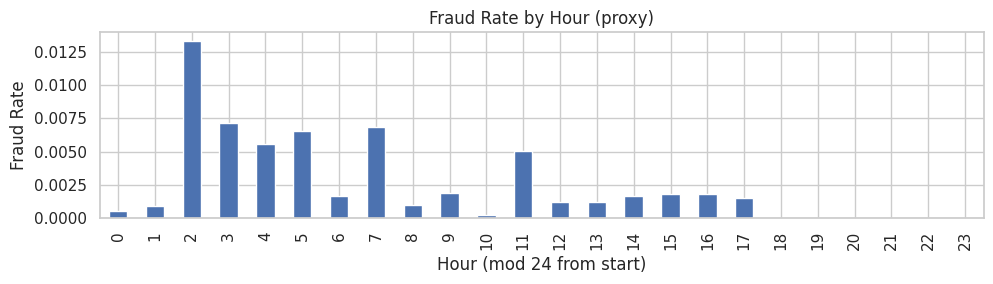

In [22]:
hour_rate = df.groupby("Hour_from_start_mod24")["Class"].mean().reindex(range(24)).fillna(0)
hour_rate.plot(kind="bar", figsize=(10,3), title="Fraud Rate by Hour (proxy)")
plt.xlabel("Hour (mod 24 from start)"); plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

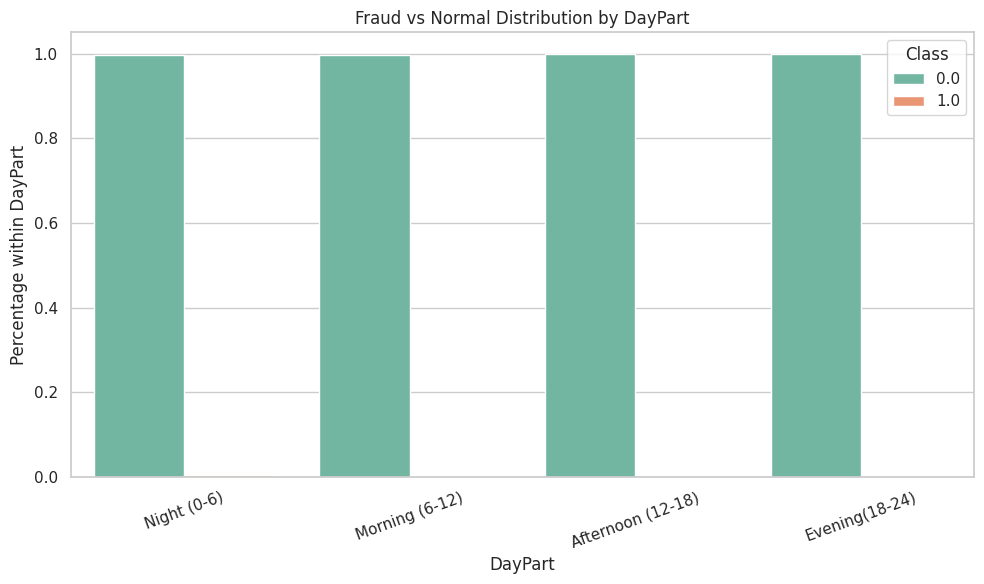

In [24]:
day_counts = df.groupby(["DayPart","Class"]).size().reset_index(name="Count")
day_total  = day_counts.groupby("DayPart")["Count"].transform("sum")
day_counts["Pct"] = day_counts["Count"] / day_total

sns.barplot(x="DayPart", y="Pct", hue="Class", data=day_counts, palette="Set2")
plt.title("Fraud vs Normal Distribution by DayPart")
plt.ylabel("Percentage within DayPart")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

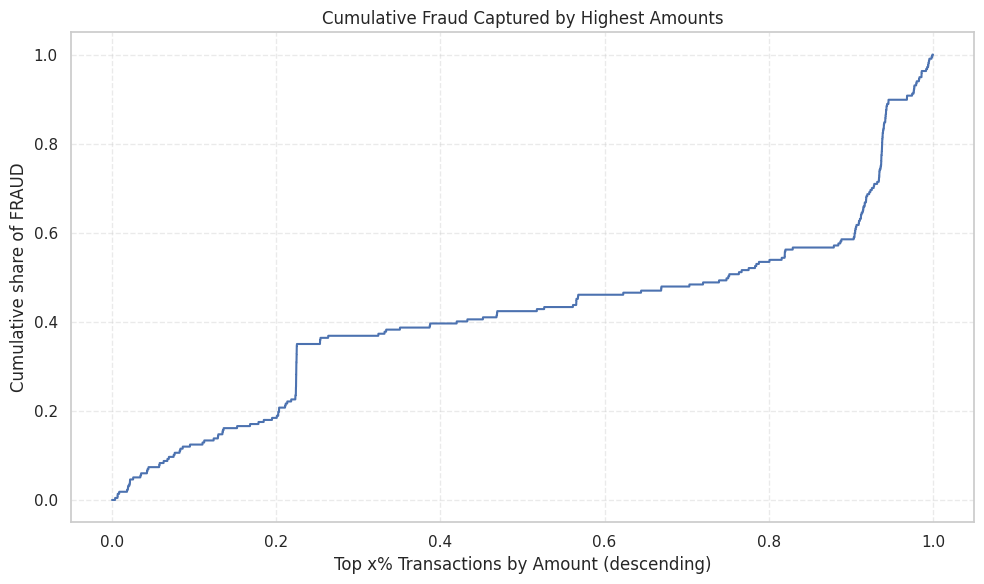

In [25]:
tmp = df[["Amount","Class"]].sort_values("Amount", ascending=False).reset_index(drop=True)
tmp["cum_tx"] = np.arange(1, len(tmp)+1) / len(tmp)
tmp["cum_fraud"] = tmp["Class"].cumsum() / tmp["Class"].sum()

plt.plot(tmp["cum_tx"], tmp["cum_fraud"])
plt.xlabel("Top x% Transactions by Amount (descending)")
plt.ylabel("Cumulative share of FRAUD")
plt.title("Cumulative Fraud Captured by Highest Amounts")
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

## ✅ Success Checklist
- Clear visualization of key feature distributions
- Identification of meaningful inter-feature relationships
- Comprehensive analysis and interpretation of outliers
- A well-structured analytical report with actionable insights

## 💡 Key Points
- EDA helps uncover patterns that could influence model performance.
- Effective visualization techniques communicate data insights persuasively.
- Analyzing outliers provides a deeper comprehension of data reliability.

## 📚 Exemplar Solution
Explore an exemplar analysis of the bike share dataset, including visual examples and explanations.

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
 # Step 0: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Setup for plotting
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

"""# Step 1: Load Dataset"""

import pandas as pd

df = pd.read_csv("bikeshareday.csv")

# Preview data
print(df.head())
print(df.info())

"""# Step 2: Visualize Feature Distributions"""

# Histogram of temperature and total rentals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['temp'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Temperature Distribution")

sns.histplot(df['cnt'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Total Rentals Distribution")

plt.tight_layout()
plt.show()

# Boxplots for outlier detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['temp'], ax=axes[0])
axes[0].set_title("Boxplot of Temperature")

sns.boxplot(y=df['cnt'], ax=axes[1])
axes[1].set_title("Boxplot of Total Rentals")

plt.tight_layout()
plt.show()

# Skewness check
print("Skewness of temp:", df['temp'].skew())
print("Skewness of count:", df['cnt'].skew())

"""# Step 3: Investigate Relationships"""

# Scatter plot: temp vs total rentals
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temperature vs. Total Rentals")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Rentals")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

"""# Step 4: Detect and Analyze Outliers"""

# Outlier detection using Z-score
z_scores = np.abs(stats.zscore(df['cnt']))
outliers_z = df[z_scores > 3]
print(f"Number of outliers in 'count' using Z-score: {len(outliers_z)}")

# Outlier detection using IQR
Q1 = df['cnt'].quantile(0.25)
Q3 = df['cnt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['cnt'] < lower_bound) | (df['cnt'] > upper_bound)]
print(f"Number of outliers in 'cnt' using IQR: {len(outliers_iqr)}")

"""# Step 5: Print Summary Report"""

print("SUMMARY REPORT")
print("\n--- Feature Distributions ---")
print("Temperature appears normally distributed; total rentals are right-skewed.")
print("Consider log-transforming 'cnt' to improve normality.")

print("\n--- Feature Relationships ---")
print("Temperature has a strong positive correlation with rental count.")
print("Humidity shows a weak or negative correlation.")

print("\n--- Outlier Analysis ---")
print(f"Z-score method found {len(outliers_z)} outliers.")
print(f"IQR method found {len(outliers_iqr)} outliers.")
print("Investigate peak usage days or anomalies before removing outliers.")

print("\n--- Modeling Implications ---")
print("Consider adding interaction terms between temperature and weather.")
print("High skew in 'cnt' may affect linear models—consider transformation.")
```    

### How does your work compare?
- Does your visualization convey data insights clearly?
- Is your correlation analysis organized and effectively presented?

## 🚀 Next Steps
Leverage your EDA insights to make informed decisions in the Feature Engineering & Selection module, optimizing your dataset for enhanced model accuracy and performance.